# Previsione dell'affidabilità creditizia per il rilascio della carta di credito <br> Master in Data Science - Profession AI <br> Virginio Cocciaglia

## Obiettivo del modello e dati disponibili

Sei stato assunto dalla **Pro National Bank** come data scientist, il tuo primo incarico consiste nel realizzare un modello in grado di stimare l'affidabilità creditizia di un cliente, al fine di aiutare il team dedicato a comprendere se accettare o meno la richiesta per il rilascio della carta di credito.
A tal fine ti vengono consegnati i dati anonimizzati di clienti che hanno già ottenuto la carta di credito e lo stato del loro debito mensile.
I dati sono organizzati in 2 file csv. Il primo, **application_record.csv**, è un dataset costituito dalle seguenti features riguardanti i clienti:
* **ID**: codice identificativo univoco del cliente.
* **CODE_GENDER**: sesso del cliente.
* **FLAG_OWN_CAR**: se possiede un'automobile.
* **FLAG_OWN_REALTY**: se possiede una proprietà.
* **CNT_CHILDREN**: numero di figli.
* **AMT_INCOME_TOTAL**: reddito annuo.
* **NAME_INCOME_TYPE**: categoria di reddito.
* **NAME_EDUCATION_TYPE**: livello di istruzione.
* **NAME_FAMILY_STATUS**: stato civile.
* **NAME_HOUSING_TYPE**: tipologia abitativa.
* **DAYS_BIRTH**: giorni trascorsi dalla nascita (si conta andando indietro dal giorno corrente 0, -1 significa ieri).
* **DAYS_EMPLOYED**: giorni trascorsi dall'inizio del lavoro (si conta andando indietro dal giorno corrente 0, se il valore è positivo significa che il cliente è attualmente disoccupato).
* **FLAG_MOBIL**: se possiede un cellulare.
* **FLAG_WORK_PHONE**: se possiede un cellulare aziendale.
* **FLAG_PHONE**: se possiede un telefono fisso.
* **FLAG_EMAIL**: se possiede una casella di posta elettronica.
* **OCCUPATION_TYPE**: tipo di occupazione.
* **CNT_FAM_MEMBERS**: numero di componenti della famiglia.

Il secondo file, **credit_record.csv**, è invece costituito da informazioni riguardanti i pagamenti dei clienti:
* **ID**: codice identificativo univoco del cliente.
* **MONTHS_BALANCE**: il mese dei dati estratti è il punto di partenza: 0 è il mese corrente, -1 è il mese precedente e così via.
* **STATUS**:
    * 0: scaduto da 1-29 giorni.
    * 1: scaduto da 30-59 giorni.
    * 2: scaduto da 60-89 giorni.
    * 3: scaduto da 90-119 giorni.
    * 4: scaduto da 120-149 giorni.
    * 5: debiti scaduti o inesigibili, più di 150 giorni.
    * C: saldati quel mese.
    * X: nessun prestito per il mese.

Il tuo modello deve essere in grado di fornire un'indicazione al team sull'approvare o meno la richiesta di carta di credito per un dato cliente. Inoltre, se ad un cliente viene negata la carta di credito, il team deve essere in grado di fornirgli una motivazione, questo vuol dire che il tuo modello deve fornire delle indicazioni facilmente interpretabili.

## Scelta della tecnica di apprendimento e del task del modello di ML

L'obiettivo del modello, come visto, è quello di stabilire l'affidabilità creditizia dei clienti per il rilascio della carta di credito fornendo una motivazione in caso di rilascio negato. Si può notare, però, tra i dati disponibili, la mancanza di una variabile target esplicita che stabilisca l'affidabilità o meno del cliente. Tuttavia, si può pensare di combinare in un'unica variabile le features *MONTHS_BALANCE* e *STATUS* ed utilizzare il pagamento o meno dei debiti nel vari mesi come target, prendendo in considerazione per ciascun cliente la modalità più frequente. In questo modo il problema può essere affrontato tramite delle tecniche di **Apprendimento Supervisionato**:
* **Classificazione Binaria** se si sceglie di raggruppare il target in una classe positiva (cliente affidabile) e in una classe negativa (cliente inaffidabile);
* **Classificazione Multiclasse** se si sceglie di raggruppare il target in più classi per dare delle informazioni più specifiche sull'affidabilità o inaffidabilità del cliente.

In entrambi i casi verrà testata l'efficacia di diversi modelli di Machine Learning o Deep Learning e scelto il "migliore".  

## Importazione delle librerie

Vengono innanzitutto importate tutte le librerie necessarie allo sviluppo del modello.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB, CategoricalNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import log_loss
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix

## Importazione e analisi descrittiva dei dataset

Viene scaricata e decompressa la cartella "credit_card_approval.zip" presente nella repository GitHub, contenente i due dataset "application_record.csv" e "credit_record.csv".

In [14]:
!wget https://github.com/VirginioC/previsione-affidabilita-creditizia-per-rilascio-carta-di-credito/raw/main/credit_card_approval.zip
!unzip credit_card_approval.zip

--2025-01-28 12:48:25--  https://github.com/VirginioC/previsione-affidabilita-creditizia-per-rilascio-carta-di-credito/raw/main/credit_card_approval.zip
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/VirginioC/previsione-affidabilita-creditizia-per-rilascio-carta-di-credito/main/credit_card_approval.zip [following]
--2025-01-28 12:48:25--  https://raw.githubusercontent.com/VirginioC/previsione-affidabilita-creditizia-per-rilascio-carta-di-credito/main/credit_card_approval.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5578875 (5.3M) [application/zip]
Saving to: ‘credit_card_approval.zip’

### Dataset 1: caratteristiche del cliente

Il primo dataset, *application_record.csv*, viene trasformato in un dataframe di pandas e viene effettuta un'analisi descrittiva delle features al suo interno.

In [15]:
CSV_APPLICATION_URL = "/content/application_record.csv"

df_1 = pd.read_csv(CSV_APPLICATION_URL)
df_1.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [ ]:
df_1.shape

(438557, 18)

In [ ]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

Il dataset è costituito da **438557 samples** di **17 features** e da **304354 samples** della feature *OCCUPATION_TYPE* che presenta 134203 dati mancanti.


#### Variabili quantitative

Le features *CNT_CHILDREN*, *DAYS_BIRTH*, *DAYS_EMPLOYED* e *CNT_FAM_MEMBERS* sono variabili quantitative discrete (int64), rappresentano dei conteggi, mentre la feature *AMT_INCOME_TOTAL* è una variabile quantitativa continua (float64). Di seguito vengono analizzate attraverso i principali indici di posizione e variabilità.

In [ ]:
quant_vars = ["CNT_CHILDREN",
              "AMT_INCOME_TOTAL",
              "DAYS_BIRTH",
              "DAYS_EMPLOYED",
              "CNT_FAM_MEMBERS"]

df_1[quant_vars].describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS
count,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.000000
mean,0.427390,1.875243e+05,-15997.904649,60563.675328,2.194465
std,0.724882,1.100869e+05,4185.030007,138767.799647,0.897207
min,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.000000
25%,0.000000,1.215000e+05,-19483.000000,-3103.000000,2.000000
50%,0.000000,1.607805e+05,-15630.000000,-1467.000000,2.000000
75%,1.000000,2.250000e+05,-12514.000000,-371.000000,3.000000
max,19.000000,6.750000e+06,-7489.000000,365243.000000,20.000000


Osservando gli indici di posizione ottenuti si può notare che il valore massimo della feature *DAYS_EMPLOYED* è pari a 365243. Tale valore positivo, stando alla descrizione della feature fornita, dovrebbe indicare che il cliente è attualmente disoccupato. Si può pertanto vedere se tutti i valori positivi presenti nel dataset sono pari a 365243.

In [ ]:
print(df_1[df_1["DAYS_EMPLOYED"]>0]["DAYS_EMPLOYED"].count())
print(df_1[df_1["DAYS_EMPLOYED"]==365243]["DAYS_EMPLOYED"].count())
print(df_1[df_1["DAYS_EMPLOYED"]==365243]["OCCUPATION_TYPE"].count())

75329
75329
0


Si conferma che a tutti i clienti disoccupati è stato assegnato il valore positivo 365243. Questo valore, però, essendo molto più grande dei restanti valori negativi può influenzare negativamente l'interpretazione della variabile da parte dei modelli che verranno creati, pertanto si prenderà in considerazione più avanti la sostituzione con un valore più ragionevole che rappresenti la condizione di disoccupazione.

Per quanto riguarda le variabili quantitative è possibile anche visualizzare la matrice di correlazione. Tale matrice, contenente i coefficienti di correlazione lineare delle variabili messe in relazione a due a due, fornisce informazioni utili sulle relazioni tra le variabili e aiuta l'eventuale feature selection nel caso siano presenti features ridondanti o non informative.

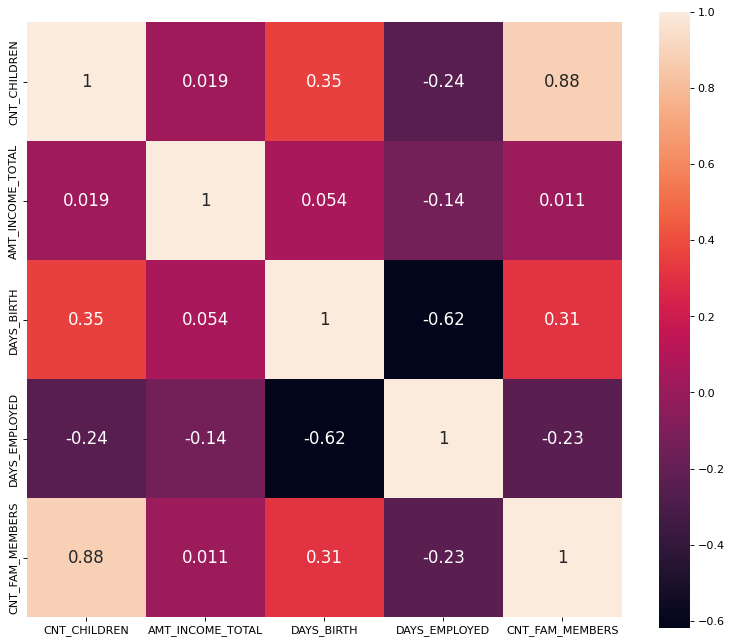

In [ ]:
plt.figure(figsize=(12, 10), dpi=80)

hm = sns.heatmap(df_1[quant_vars].corr(),
                 cbar=True,
                 square=True,
                 annot=True,
                 annot_kws={'size':15})

plt.show()

Dalla matrice di correlazione si evince che le features che sono maggiormente correlate tra di loro sono *CNT_CHILDREN* e *CNT_FAM_MEMBERS*: coefficiente di correlazione lineare pari a 0.88 che sta ad indicare una forte correlazione positiva. Questa risultato può essere confermato anche a livello intuitivo dato che maggiore è il numero di figli maggiore è il numero di componenti della famiglia. Anche le features *DAYS_BIRTH* e *DAYS_EMPLOYED* risultano essere abbastanza correlate tra di loro, in questo caso negativamente (-0.62) poichè sia i giorni trascorsi dalla nascita che i giorni trascorsi dall'inizio del lavoro crescono negativamente a partire dal giorno corrente. Tale risultato, anche in questo caso, è facilmente confermabile a livello intuitivo. Non sono presenti altre correlazioni degne di nota.



#### Variabili qualitative

Le features *FLAG_MOBIL*,	*FLAG_WORK_PHONE*, *FLAG_PHONE* e *FLAG_EMAIL*	 sono variabili dummy: variabili qualitative nominali binarie codificate per assumere il valore 0 o 1 (int64). Anche le features *CODE_GENDER*, *FLAG_OWN_CAR* e *FLAG_OWN_REALTY* sono variabili qualitative nominali binarie ma non sono codificate e sono pertanto delle stringhe (object). Infine, le features *ID*, *NAME_INCOME_TYPE*, *NAME_EDUCATION_TYPE*, *NAME_FAMILY_STATUS*, *NAME_HOUSING_TYPE* e *OCCUPATION_TYPE* sono variabili qualitative sconnesse (object). Di seguito vengono ricavate le frequenze delle diverse modalità delle precedenti variabili.

In [ ]:
qual_vars = [col for col in df_1.columns if col not in quant_vars]
qual_vars

['ID',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'FLAG_MOBIL',
 'FLAG_WORK_PHONE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE']

In [ ]:
for var in qual_vars:
    counts = df_1[var].value_counts()
    perc = (df_1[var].value_counts(normalize=True)*100).round(2)

    var_df = pd.DataFrame({"Counts": counts, "Percentages": perc})
    var_df.index.name = var

    print(var_df)
    print("---------------------------------------------------")

         Counts  Percentages
ID                          
7137299       2          0.0
7702238       2          0.0
7282535       2          0.0
7243768       2          0.0
7050948       2          0.0
...         ...          ...
5690727       1          0.0
6621262       1          0.0
6621261       1          0.0
6621260       1          0.0
6842885       1          0.0

[438510 rows x 2 columns]
---------------------------------------------------
             Counts  Percentages
CODE_GENDER                     
F            294440        67.14
M            144117        32.86
---------------------------------------------------
              Counts  Percentages
FLAG_OWN_CAR                     
N             275459        62.81
Y             163098        37.19
---------------------------------------------------
                 Counts  Percentages
FLAG_OWN_REALTY                     
Y                304074        69.34
N                134483        30.66
------------------------

Per prima cosa si può osservare come alcuni codici identificativi dei clienti siano presenti due volte nel dataset (vi sono 438510 ID differenti tra di loro e tra questi 47 sono ripetuti due volte). Bisogna pertanto capire se vi sono dei samples duplicati nel dataset oppure se vi è stato qualche tipo di errore nella produzione dei dati.

In [ ]:
df_1_no_duplicates = df_1.drop_duplicates()
df_1_no_duplicates.shape

(438557, 18)

Dopo aver eliminato eventuali samples duplicati con *drop_duplicates* le dimensioni del dataset sono rimaste invariate, pertanto si deduce che a ID uguali corrispondono informazioni differenti. Considerando la volontà di avere un ID univoco per ciascun cliente si dovrà in seguito procedere all'eliminazione dei samples con questi 47 ID e dei loro altrettanti duplicati. <br>
Analizzando le statistiche ottenute per le restanti features, si può notare come in tutti i casi le classi risultino essere sbilanciate tra di loro ad eccezione della feature binaria *FLAG_MOBIL* che assume soltanto il valore positivo indicando che tutti i clienti possiedono un cellulare. Tale feature, pertanto, non dando nessun tipo di informazione utile potrà essere non considerata nella creazione del modello. Inoltre, è bene ricordare anche che la feature *OCCUPATION_TYPE* presenta 134203 dati mancanti e si dovrà scegliere come comportarsi con essa in fase di preprocessing.

### Dataset 2: storico dei pagamenti del cliente

Così come avvenuto per il primo dataset, anche il secondo dataset *credit_record.csv* viene trasformato in un dataframe di pandas e viene effettuta un'analisi descrittiva delle features al suo interno.

In [ ]:
CSV_CREDIT_URL = "/content/credit_record.csv"

df_2 = pd.read_csv(CSV_CREDIT_URL)
df_2.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
df_2.shape

(1048575, 3)

In [ ]:
df_2_no_duplicates = df_2.drop_duplicates()
df_2_no_duplicates.shape

(1048575, 3)

In [ ]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


Il dataset è costituito da **1048575 samples** di **3 features** e non sono presenti samples duplicati. Tali features, già descritte in precedenza, sono il codice identificativo univoco del cliente *ID*, i mesi trascorsi dal rilascio della carta *MONTHS_BALANCE* e lo stato dei pagamenti del cliente per ciascun mese *STATUS*. Ciascuna di queste features può essere considerata come una variabile qualitativa sconnessa. Di seguito vengono ricavate le frequenze delle diverse modalità delle precedenti variabili.

In [ ]:
variables = ["ID", "MONTHS_BALANCE", "STATUS"]

for var in variables:
    counts = df_2[var].value_counts()
    perc = (df_2[var].value_counts(normalize=True)*100).round(2)

    var_df = pd.DataFrame({"Counts": counts, "Percentages": perc})
    var_df.index.name = var

    print(var_df)
    print("------------------------------------")

         Counts  Percentages
ID                          
5016769      61         0.01
5002806      61         0.01
5118192      61         0.01
5145767      61         0.01
5078567      61         0.01
...         ...          ...
5028795       1         0.00
5148442       1         0.00
5053900       1         0.00
5046332       1         0.00
5079047       1         0.00

[45985 rows x 2 columns]
------------------------------------
                Counts  Percentages
MONTHS_BALANCE                     
-1               34436         3.28
-2               34209         3.26
 0               33856         3.23
-3               33854         3.23
-4               33365         3.18
...                ...          ...
-56               2109         0.20
-57               1649         0.16
-58               1255         0.12
-59                820         0.08
-60                415         0.04

[61 rows x 2 columns]
------------------------------------
        Counts  Percentages
STAT

Si osserva come in questo secondo dataset siano presenti 45985 ID diversi a differenza del primo dataset in cui ci sono 438510 ID. Inoltre si osserva come il conteggio degli ID va da 1 a 61 indicando che ci sono clienti che hanno la carta di credito da solo un mese e clienti che invece la posseggono da circa 5 anni. Le frequenze della feature *MONTH_BALANCE* invece mostrano che i dati sui nuovi clienti sono molto più frequenti rispetto a quelli sui clienti più "vecchi". Infine, le frequenze della feature *STATUS*, indicano che prendendo in considerazione la totalità dei clienti e dei mesi i debiti saldati sono i più frequenti: classe C con il 42.16 %.

## Preprocessing dei dati

### Creazione della variabile target RELIABILITY

Come già detto in precedenza, nei due dataset non è presente un target esplicito che permette l'utilizzo di tecniche di apprendimento supervisionato, tuttavia, è possibile combinare in un'unica variabile le features *MONTHS_BALANCE* e *STATUS* ed utilizzare il pagamento o meno dei debiti nei vari mesi come target, prendendo in considerazione per ciascun cliente la modalità più frequente. Tale target verrà chiamato ***RELIABILITY*** e sarà un indicatore di affidabilità.





Per fare ciò, è innanzitutto necessario stabilire in quante classi si vuole suddividire il target. Un'opzione ragionevole per il presente problema è quella di suddividere il target in 3 classi:
* **Classe I (Indefinite Reliability)**: il cliente non ha mai richiesto un prestito (nello storico la feature *STATUS* assume soltanto la modalità X); tale informazione non permette di stabilire l'affidabilità o meno del cliente che è rimessa alla stessa banca.
* **Classe R (Reliable Customer)**: il cliente è affidabile perchè per la maggior parte dei mesi ha pagato i suoi debiti (modalità più frequente di *STATUS*: C).
* **Classe U (Unreliable Customer)**: il cliente è inaffidabile perchè per la maggior parte dei mesi non ha pagato i suoi debiti (modalità più frequente di *STATUS*: 0, 1, 2, 3, 4 o 5).

Con queste tre classi si è in grado di dare delle indicazioni facilmente interpretabili al team sull'approvare o meno la richiesta di carta di credito per un dato cliente.


Prima di poter ingegnerizzare il target, però, è necessario mappare la feature *STATUS* in maniera tale che le modalità da 0 a 5 vengano considerate parte di un'unica classe 0-5.

In [ ]:
status_mapping = {"X": "X",
                  "C": "C",
                  "0": "0-5",
                  "1": "0-5",
                  "2": "0-5",
                  "3": "0-5",
                  "4": "0-5",
                  "5": "0-5"}

df_2["STATUS"] = df_2["STATUS"].map(status_mapping)

df_2.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0-5
2,5001711,-2,0-5
3,5001711,-3,0-5
4,5001712,0,C


In [ ]:
df_2.shape

(1048575, 3)

In [ ]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


A questo punto è possibile creare il target *RELIABILITY* andando a costruire un dataframe in cui per ciascun ID univoco del cliente si ha una delle tre classi precedentemente descritte: **I** se il cliente ha nello storico solo X, **U** se la classe più frequente di *STATUS* è 0-5 ed **R** se la classe più frequente è C. Nel caso in cui i clienti abbiano le classi della variabile *STATUS* C e 0-5 con la stessa frequenza si assegna automaticamente la classe di *RELIABILITY* R preferendo non perdere clienti potenzialmente affidabili.

In [ ]:
status_counts = df_2.groupby(["ID", "STATUS"]).size().unstack()

only_X_clients = status_counts.index[
    status_counts["X"] == status_counts.sum(axis=1)]

ties_clients = status_counts.index[
    status_counts["0-5"] == status_counts["C"]].tolist()

others_clients = status_counts.index.difference(
    only_X_clients.union(ties_clients))

ties_count = len(ties_clients)
print(f"Number of ties between '0-5' and 'C': {ties_count}")

results = []

for client in only_X_clients:
    results.append({"ID": client, "RELIABILITY": "I"})

for client in ties_clients:
    results.append({"ID": client, "RELIABILITY": "R"})

for client in others_clients:
    client_status_counts = status_counts.loc[client]
    unique_statuses = client_status_counts.unique()

    if len(unique_statuses) == 1:
        if unique_statuses[0] == "C":
            reliability = "R"
        elif unique_statuses[0] == "0-5":
            results.append({"ID": client, "RELIABILITY": "U"})
    else:
        most_freq_class = client_status_counts.idxmax()

        if most_freq_class == "C":
            reliability = "R"
        elif most_freq_class == "0-5":
            reliability = "U"

    results.append({"ID": client, "RELIABILITY": reliability})

df_2_agg = pd.DataFrame(results)

print()

df_2_agg

Number of ties between '0-5' and 'C': 650



,ID,RELIABILITY
0,5001713,I
1,5001714,I
2,5001715,I
3,5001731,I
4,5001732,I
...,...,...
45980,5150480,R
45981,5150482,U
45982,5150484,U
45983,5150485,U


In [ ]:
df_2_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45985 entries, 0 to 45984
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           45985 non-null  int64 
 1   RELIABILITY  45985 non-null  object
dtypes: int64(1), object(1)
memory usage: 718.6+ KB


In [ ]:
counts_reliability = df_2_agg["RELIABILITY"].value_counts()
perc_reliability = (df_2_agg["RELIABILITY"].value_counts(normalize=True)*100).round(2)

reliability_df = pd.DataFrame({"Counts": counts_reliability,
                               "Percentages": perc_reliability})

reliability_df.sort_values(by="Percentages")

,Counts,Percentages
RELIABILITY,,
I,4536,9.86
R,18486,40.20
U,22963,49.94


Associando ad ogni cliente la sua classe del target *RELIABILITY* è stato ottenuto un dataset costituito da 45985 samples (in precedenza si è visto che 45985 è il numero di ID presenti nel *df_2* a conferma della bontà del processo). Il target ingegnerizzato ha le classi distribuite nel seguente modo:

* **Classe I (Indefinite Reliability)**: 9.86 % del dataset.
* **Classe R (Reliable Customer)**: 40.20 % del dataset.
* **Classe U (Unreliable Customer)**: 49.24 % del dataset.

Si osserva, dunque, che le classi riguardanti i clienti affidabili e non affidabili sono abbastanza bilanciate tra di loro mentre la classe riguardante i clienti che non hanno mai richiesto debiti ha molti meno elementi al suo interno. Si dovrà, pertanto, prendere in considerazione tale sbilanciamento durante la costruzione dei modelli.



### Creazione di un unico dataset con tutte le informazioni

Una volta ottenuto il *df_2_agg* con il target ingegnerizzato è possibile unirlo al *df_1* in modo tale da creare un unico dataset costituito dagli ID dei clienti in comune ai due dataset con le relative informazioni.

#### Preprocessing del dataset 1

Prima di poter unificare i dataset è però necessario effettuare alcune modifiche al dataset 1 scaturite dalla precedente analisi descrittiva :
* **Sostituzione dei valori 365243 della feature *DAYS_EMPLOYED***: si è visto in precedenza che tali valori, rappresentativi dei clienti disoccupati, possono portare problemi di interpretazione della feature, pertanto, si procederà a sostituirli con degli 1 (valori sempre positivi ma ragionevoli).
* **Rimozione dei samples in cui si ha lo stesso ID**: si è visto che sono presenti 47 samples che hanno l'ID ripetuto due volte. Non si tratta però di samples duplicati con le stesse features pertanto verranno rimossi tutti i samples con questi ID per un totale di 94 righe.
* **Rimozione della feature *FLAG_MOBIL***: tale feature assume solo ed esclusivamente la modalità positiva (*FLAG_MOBIL*=1) pertanto non è informativa.
* **Rimozione della feature *OCCUPATION_TYPE***: si è visto che questa feature ha 304354 valori validi e 134203 dati mancanti. Considerando che questi dati mancanti sono circa il 30 % del totale l'opzione migliore sembra essere l'eliminazione totale della feature.

In [ ]:
df_1["DAYS_EMPLOYED"].replace(365243, 1, inplace=True)

df_1["DAYS_EMPLOYED"].value_counts()

DAYS_EMPLOYED
 1        75329
-218        262
-1678       251
-249        241
-978        240
          ...  
-13529        1
-10223        1
-8917         1
-11429        1
-8105         1
Name: count, Length: 9406, dtype: int64

In [ ]:
print(f"Size of dataset before removal of duplicates: {df_1.shape}")

df_1 = df_1.drop_duplicates(subset=["ID"], keep=False)

print(f"Size of dataset after removing duplicates: {df_1.shape}")

print()

print(df_1["ID"].value_counts())

Size of dataset before removal of duplicates: (438557, 18)
Size of dataset after removing duplicates: (438463, 18)

ID
5008804    1
6147691    1
6147689    1
6147688    1
6147685    1
          ..
6093492    1
5690720    1
6538938    1
6538937    1
6842885    1
Name: count, Length: 438463, dtype: int64


In [ ]:
df_1 = df_1.drop(["FLAG_MOBIL", "OCCUPATION_TYPE"],  axis=1)
df_1.shape

(438463, 16)

#### Dataset unico con features e target: dataset df

A questo punto si può procedere con la creazione di un unico dataset con le features e il target *RELIABILITY* che verrà chiamato *df*.

In [ ]:
df = pd.merge(df_1, df_2_agg, on="ID", how="inner")

df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,RELIABILITY
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,2.0,R
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,2.0,R
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,0,0,0,2.0,R
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,1.0,R
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,1.0,I


Inoltre, ora che sono stati unificati i due dataset è possibile anche eliminare la colonna *ID* non essendo informativa per il modello.

In [ ]:
df = df.drop(["ID"],  axis=1)

In [ ]:
df.shape

(36457, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CODE_GENDER          36457 non-null  object 
 1   FLAG_OWN_CAR         36457 non-null  object 
 2   FLAG_OWN_REALTY      36457 non-null  object 
 3   CNT_CHILDREN         36457 non-null  int64  
 4   AMT_INCOME_TOTAL     36457 non-null  float64
 5   NAME_INCOME_TYPE     36457 non-null  object 
 6   NAME_EDUCATION_TYPE  36457 non-null  object 
 7   NAME_FAMILY_STATUS   36457 non-null  object 
 8   NAME_HOUSING_TYPE    36457 non-null  object 
 9   DAYS_BIRTH           36457 non-null  int64  
 10  DAYS_EMPLOYED        36457 non-null  int64  
 11  FLAG_WORK_PHONE      36457 non-null  int64  
 12  FLAG_PHONE           36457 non-null  int64  
 13  FLAG_EMAIL           36457 non-null  int64  
 14  CNT_FAM_MEMBERS      36457 non-null  float64
 15  RELIABILITY          36457 non-null 

In definita, si è giunti ad avere un unico dataset costituito da **36457 samples** (pari al numero di ID in comune tra *df_1* e *df_2_agg*) con **15 features** più il **target** ***RELIABILITY***.<br>
Infine, ora che è il dataset è stato unificato e diversi samples con ID non in comune sono stati eliminati (si è passati da 45985 samples a 36457 samples) è necessario ricalcolare la distribuzione delle classi del target.

In [ ]:
counts_reliability = df["RELIABILITY"].value_counts()
perc_reliability = (df["RELIABILITY"].value_counts(normalize=True)*100).round(2)

reliability_df = pd.DataFrame({"Counts": counts_reliability,
                               "Percentages": perc_reliability})

reliability_df.sort_values(by="Percentages")

,Counts,Percentages
RELIABILITY,,
I,3347,9.18
R,14307,39.24
U,18803,51.58


La distribuzione delle classi del target *RELIABILITY* è rimasta quasi la stessa anche dopo aver unificato i due dataset.

### Analisi descrittiva del comportamento delle features in relazione al target

In precedenza è stata effettuata l'analisi descrittiva dei due dataset prendendo in considerazione le singole features. Ora che, però, è stato ingegnerizzato il target risulta possibile e opportuno confrontare ciascuna feature con esso.

#### Variabili quantitative vs target

Di seguito verranno confrontate le variabili quantitative del dataset unificato *df* (stesse variabili quantitative del primo dataset *df_1*: *quant_vars*) con il target *RELIABILITY* attraverso dei boxplot.

In [ ]:
quant_vars

['CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'CNT_FAM_MEMBERS']

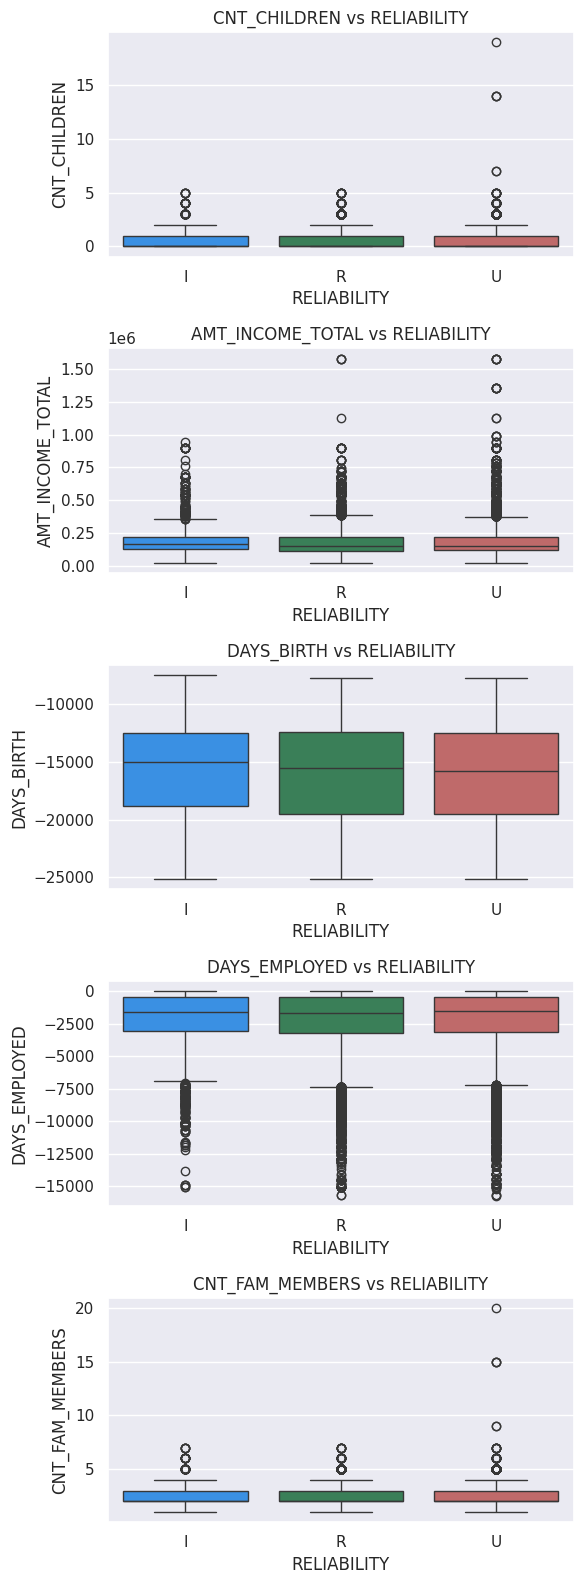

In [ ]:
sns.set_theme(palette="dark")

fig, axes = plt.subplots(5, 1, figsize=(6, 16))

reliability_order = ["I", "R", "U"]

for i, var in enumerate(quant_vars):
    sns.boxplot(x="RELIABILITY",
                y=var,
                data=df,
                order=reliability_order,
                hue="RELIABILITY",
                hue_order=reliability_order,
                palette=["dodgerblue", "seagreen", "indianred"],
                legend=False,
                ax=axes[i])
    axes[i].set_title(f"{var} vs RELIABILITY")

plt.tight_layout()
plt.show()

Dai risultati ottenuti con i boxplot sembrerebbe che tali variabili quantitative, prese singolarmente, non influenzino significativamente il target. Per ogni feature, infatti, i boxplot suddivisi per classe di *RELIABILITY* sono molto simili tra di loro.

#### Variabili qualitative vs target

Le variabili qualitative, invece, vengono messe a confronto con il target *RELIABILITY* attraverso dei grafici a barre affiancate normalizzati: per ciascuna modalità delle variabili qualitative vengono mostrate le proporzioni di clienti affidabili ("R"), inaffidabili ("U") e indefinibili ("I"). In questo caso, le variabili qualitative non sono le stesse del *df_1* essendo state eliminate le variabili *ID* e *OCCUPATION_TYPE*.

In [ ]:
qual_vars = [col for col in df.columns if col not in quant_vars and col != "RELIABILITY"]
qual_vars

['CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'FLAG_WORK_PHONE',
 'FLAG_PHONE',
 'FLAG_EMAIL']

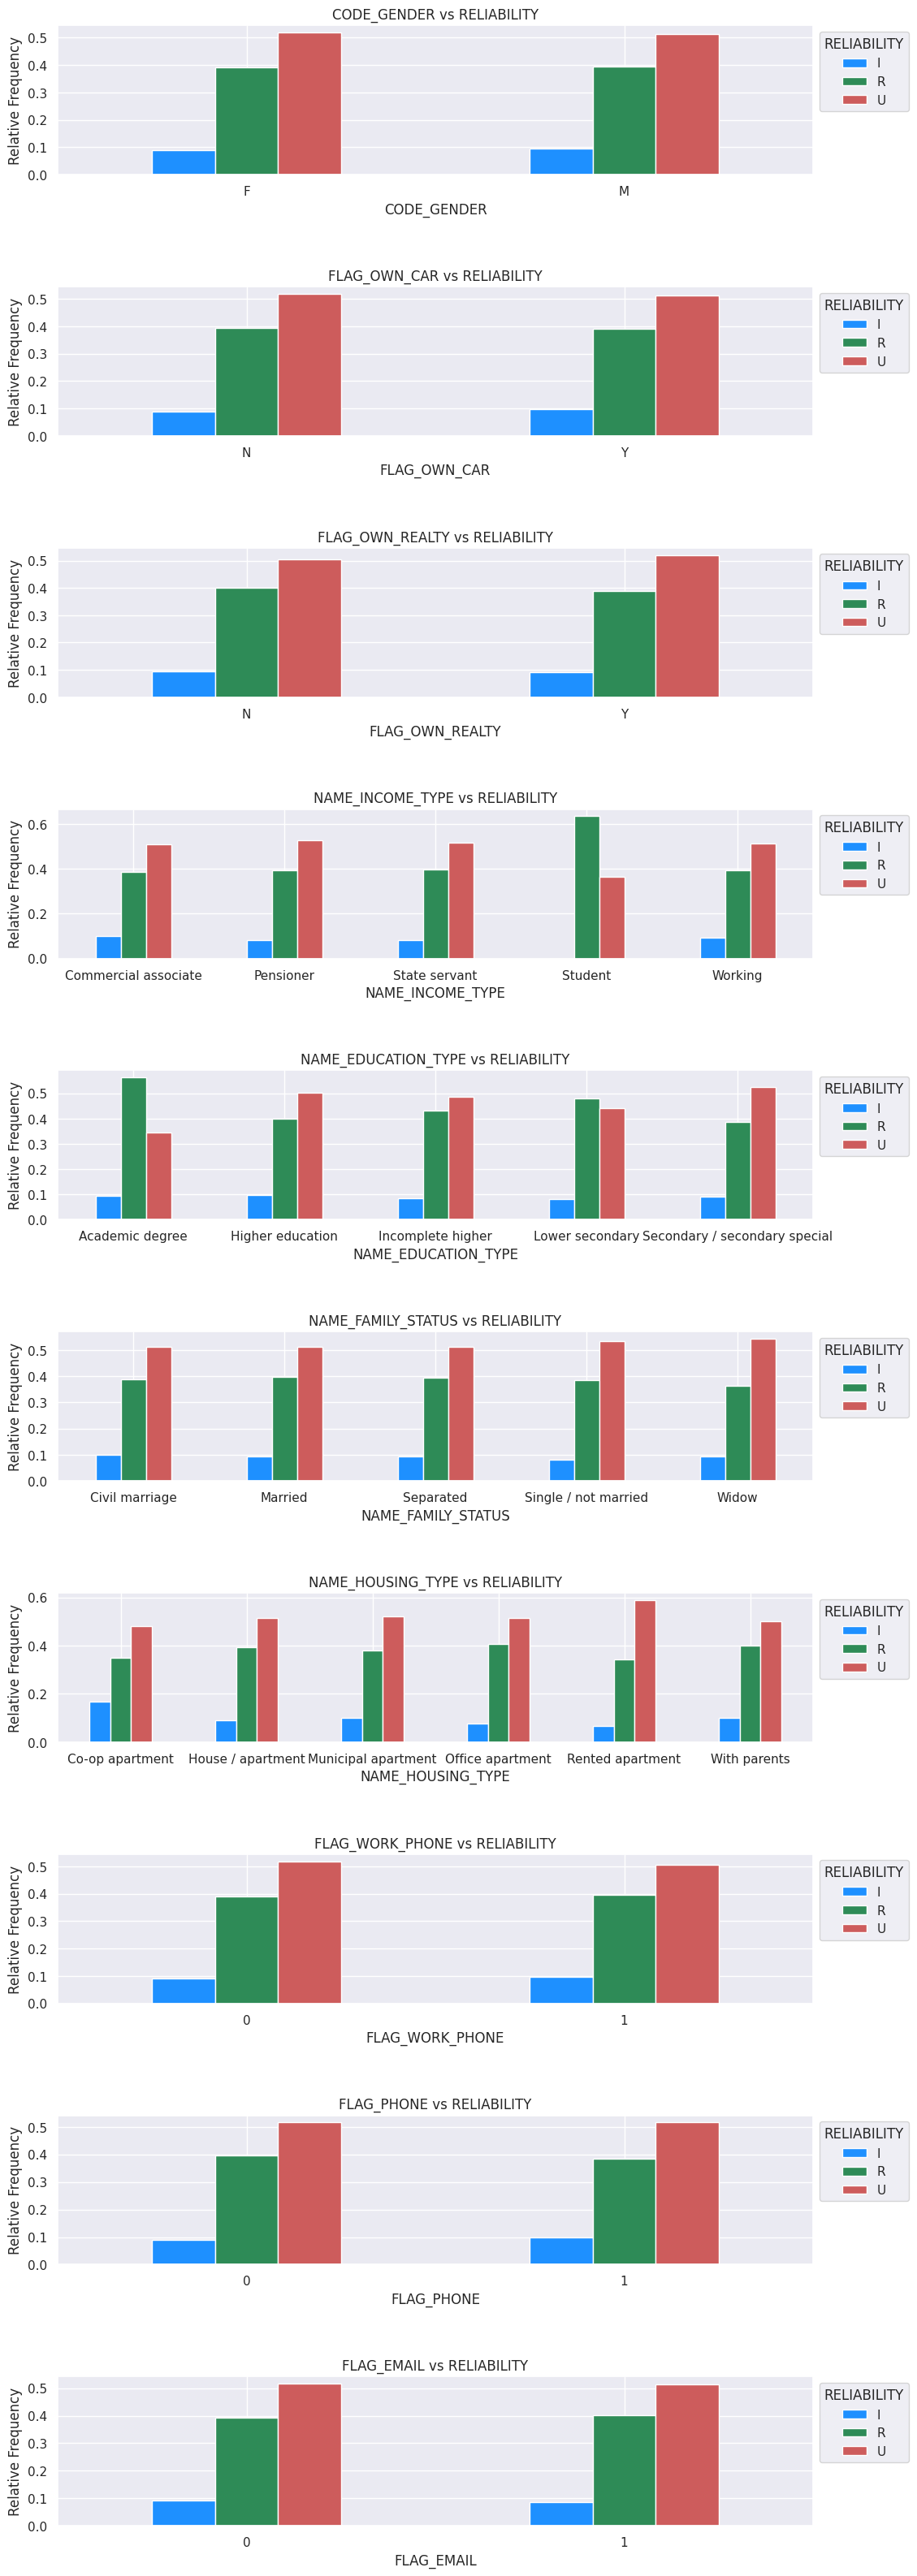

In [ ]:
sns.set_theme(palette="dark")

fig, axes = plt.subplots(10, 1, figsize=(12, 40))

palette=["dodgerblue", "seagreen",  "indianred"]

for i, var in enumerate(qual_vars):
    freq_table = df.groupby([var, "RELIABILITY"]).size().unstack()
    relative_freq = freq_table.div(freq_table.sum(axis=1), axis=0)

    relative_freq.plot(kind="bar", stacked=False, ax=axes[i], color=palette)

    axes[i].set_title(f"{var} vs RELIABILITY")
    axes[i].set_ylabel("Relative Frequency")
    axes[i].legend(title="RELIABILITY",
                   loc="upper left",
                   bbox_to_anchor=(1,1),
                   ncol=1)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.subplots_adjust(hspace=0.75)
plt.show()

Grazie ai precedenti barplot si deducono le seguenti informazioni:
* Le features binarie *CODE_GENDER*, *FLAG_OWN_CAR*, *FLAG_OWN_REALTY*, *FLAG_WORK_PHONE*, *FLAG_PHONE* e *FLAG_EMAIL* hanno le due modalità distribuite in maniera quasi identica per ciascuna delle tre classi del target *RELIABILITY*. Tale distribuzione rispecchia quella totale delle classi del target, considerando tutto il dataset: circa 52 % per "U", 39 % per "R" e 9 % per "I".  
* La feature *NAME_INCOME_TYPE* ha le categorie *Commercial associate*, *Pensioner*, *State servant* e *Working* distribuite in maniera proporzionale alla distribuzione totale delle classi del target. La categoria *Student*, invece, è distribuita per circa il 62 % sulla classe "R" e per circa il 38 % sulla classe "U". Dunque si deduce che nel caso in cui la categoria di reddito è legata all'essere studenti la maggior parte dei clienti è affidabile e non sono presenti clienti che non hanno mai richiesto prestiti. Anche se bisogna tenere in considerazione che si è visto in precedenza che questa categoria è la meno presente nel dataset: sono presenti soltanto 17 clienti il cui reddito è legato all'essere degli studenti.
* La feature *NAME_EDUCATION_TYPE* ha le categorie *Higher education* e *Secondary / secondary special* distribuite in maniera simile alla distribuzione totale delle classi del target e la categoria *Incomplete higher* con una distribuzione simile ma con le classi "U" ed "R" più vicine tra di loro. La categoria *Lower secondary*, invece, ha la classe "R" leggermente più presente rispetto alla classe "U". Infine, la categoria *Academic degree*, che è anche la meno numerosa, ha la classe "R" presente con molta più frequenza rispetto alla classe "U".
* La feature *NAME_FAMILY_STATUS* ha tutte le categorie distribuite in maniera simile alla distribuzione totale delle classi del target.
* La feature *NAME_HOUSING_TYPE* ha le categorie *House / apartment*, *Municipal apartment*, *Office apartment* e *With parents* distribuite in maniera simile alla distribuzione totale delle classi del target. La categoria *Rented apartment*, invece, ha la classe "U" molto più presente rispetto alla classe "R". Infine, la categoria *Co-op apartment*, la meno numerosa, si discosta dalla distribuzione totale delle classi del target poichè la classe "I" è presente maggiormente e le altre classi sono meno frequenti.

### Features e target encoding

Dunque, dopo varie operazioni di preprocessing si è giunti ad avere un unico dataset. Di seguito vengono riportati nuovamente i primi 5 samples e le informazioni sul dataset.

In [ ]:
df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,RELIABILITY
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,2.0,R
1,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,2.0,R
2,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,0,0,0,2.0,R
3,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,1.0,R
4,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,1.0,I


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CODE_GENDER          36457 non-null  object 
 1   FLAG_OWN_CAR         36457 non-null  object 
 2   FLAG_OWN_REALTY      36457 non-null  object 
 3   CNT_CHILDREN         36457 non-null  int64  
 4   AMT_INCOME_TOTAL     36457 non-null  float64
 5   NAME_INCOME_TYPE     36457 non-null  object 
 6   NAME_EDUCATION_TYPE  36457 non-null  object 
 7   NAME_FAMILY_STATUS   36457 non-null  object 
 8   NAME_HOUSING_TYPE    36457 non-null  object 
 9   DAYS_BIRTH           36457 non-null  int64  
 10  DAYS_EMPLOYED        36457 non-null  int64  
 11  FLAG_WORK_PHONE      36457 non-null  int64  
 12  FLAG_PHONE           36457 non-null  int64  
 13  FLAG_EMAIL           36457 non-null  int64  
 14  CNT_FAM_MEMBERS      36457 non-null  float64
 15  RELIABILITY          36457 non-null 

Tuttavia, le operazioni di data preprocessing non sono ancora terminate poichè analizzando il dataset si possono osservare diverse variabili qualitative che necessitano di essere codificate.

#### Label Encoding

Le features *CODE_GENDER*, *FLAG_OWN_CAR* e *FLAG_OWN_REALTY* sono variabili qualitative nominali binarie ma non sono codificate e sono pertanto delle stringhe (object). Per questo motivo, è necessario codificarle rendendole numeriche in modo da poter essere utilizzate per la creazione del modello di classificazione. Si procede allora di seguito ad utilizzare il **Label Encoding** su di esse per trasformarle in variabili dummy (0 oppure 1) utilizzando il trasformatore *LabelEncoder* di scikit-learn.

In [ ]:
le = LabelEncoder()

var_le = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY"]

df[var_le] = df[var_le].apply(lambda col: le.fit_transform(col))
df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,RELIABILITY
0,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,2.0,R
1,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,2.0,R
2,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,0,0,0,2.0,R
3,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,1.0,R
4,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,1.0,I


In [ ]:
df.shape

(36457, 16)

#### One-Hot Encoding

Le features *NAME_INCOME_TYPE*, *NAME_EDUCATION_TYPE*, *NAME_FAMILY_STATUS* e *NAME_HOUSING_TYPE* sono variabili qualitative sconnesse (object), perciò, in questo caso, non avendo delle categorie ordinabili viene utilizzando il **One-Hot Encoding** con il metodo *get_dummies* di pandas. Si ottiene, in questo modo, una colonna per ciascuna categoria dove la categoria presente vale 1 e le restanti 0.<br> È importante sottolineare che anche il target *RELIABILITY* è una variabile qualitativa sconnessa ma non è richiesta nessuna codifica poichè scikit-learn, nella costruzione dei suoi modelli di previsione, è in grado di gestire correttamente le classi anche se sono stringhe.

In [ ]:
var_ohe = ["NAME_INCOME_TYPE",
           "NAME_EDUCATION_TYPE",
           "NAME_FAMILY_STATUS",
           "NAME_HOUSING_TYPE"]

df = pd.get_dummies(df, columns=var_ohe, dtype=int)
df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,...,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents
0,1,1,1,0,427500.0,-12005,-4542,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,1,1,1,0,427500.0,-12005,-4542,1,0,0,...,0,0,0,0,0,0,0,0,1,0
2,1,1,1,0,112500.0,-21474,-1134,0,0,0,...,1,0,0,0,0,1,0,0,0,0
3,0,0,1,0,270000.0,-19110,-3051,0,1,1,...,0,0,1,0,0,1,0,0,0,0
4,0,0,1,0,270000.0,-19110,-3051,0,1,1,...,0,0,1,0,0,1,0,0,0,0


In [ ]:
df.shape

(36457, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 33 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   CODE_GENDER                                        36457 non-null  int64  
 1   FLAG_OWN_CAR                                       36457 non-null  int64  
 2   FLAG_OWN_REALTY                                    36457 non-null  int64  
 3   CNT_CHILDREN                                       36457 non-null  int64  
 4   AMT_INCOME_TOTAL                                   36457 non-null  float64
 5   DAYS_BIRTH                                         36457 non-null  int64  
 6   DAYS_EMPLOYED                                      36457 non-null  int64  
 7   FLAG_WORK_PHONE                                    36457 non-null  int64  
 8   FLAG_PHONE                                         36457 non-null  int64  
 9   FLAG_E

Dunque, dopo aver codificato le variabili qualitative sconnesse si è arrivati ad avere un dataset costiuito da **33 colonne** invece di 16, con **36457 samples**.

## Scelta dei modelli da costruire e valutare

Alla luce del modo in cui è stato ingegnerizzato il target *RELIABILITY*, il modello di previsione dell'affidabilità creditizia dei clienti per il rilascio della carta di credito sarà un modello di **Classificazione Multiclasse**: "R" se il cliente è affidabile, "U" se il cliente è inaffidabile ed "I" se non è possibile stabilire l'affidabilità. Dunque, verrano creati e valutati, alla ricerca del "migliore", i seguenti modelli di classificazione:
* **Regressione Logistica**
* **Modelli Naive Bayes**
* **Support Vector Machines**
* **Decison Tree**
* **Random Forest**
* **Multilayer Perceptron**

## Metriche utilizzate per la valutazione dei modelli e loro importanza in base all'obiettivo aziendale

Le metriche che verranno calcolate per valutare la bontà dei modelli di classificazione sono le seguenti:
1. **Precision**: percentuale delle classificazioni appartenenti ad una delle tre classi che sono effettivamente appartenenti a quella classe.
2. **Recall**: percentuale delle osservazioni appartenenti ad una delle tre classi che vengono classificate come appartenenti a quella classe.
4. **Accuracy**: percentuale di classificazioni corrette.
5. **AUC**: area sotto alla curva ROC (misura della capacità del modello di classificazione di distinguere tra le diverse classi). <br>

Una volta trovato il modello che si ritiene essere il migliore, verrà ricavata anche la **Matrice di Confusione** che riassume visivamente le performance del modello. <br>
L'obiettivo, chiaramente, è quello di ottenere delle buone metriche per ciascuna delle tre classi, tuttavia, qualora non fosse possibile particolare attenzione verrà rivolta alle classi maggioritarie R (clienti affidabili) ed U (clienti inaffidabili). Le metriche e le classi da ottimizzare, infatti, dipendono dalla politica aziendale della banca riguardo al **rischio di insolvenza rispetto alla perdita di clienti affidabili** e si possono ipotizzare due situazioni:
1. **Politica di assunzione del rischio** <br>
    1.1 **Espansione della base clienti**: la banca ha un interesse significativo nell'espandere la propria base di clienti. Rilasciare carte di credito anche a clienti con un profilo di rischio più alto può portare a maggiori entrate, poiché questi clienti tendono a utilizzare più spesso il credito e quindi pagare più interessi e commissioni.<br>
    1.2 **Diversificazione del rischio**: offrire carte di credito a una varietà di clienti, inclusi quelli potenzialmente inaffidabili, può essere una strategia di diversificazione del rischio. La perdita derivante da alcuni clienti insolventi può essere compensata dagli utili generati dai clienti affidabili.
2. **Politica di riduzione del rischio** <br>
    2.1 **Prevenzione delle perdite**: la banca preferisce evitare perdite significative escludendo i clienti potenzialmente inaffidabili. Le perdite da insolvenza possono avere un impatto negativo sui bilanci e sul rating di credito della banca stessa.<br>
    2.2 **Protezione del portafoglio clienti**: mantenere una base di clienti affidabile e di alta qualità può migliorare la stabilità finanziaria della banca.

In questo caso si ipotizza che la banca abbia necessità di adottare una **politica di assunzione del rischio** e pertanto l'obiettivo è quello di massimizzare la **recall** della **classe R** (Reliable Customer). In questo modo vengono ridotti al minimo i clienti affidabili che vengono classificati come inaffidabili oppure indefiniti così da non perdersi nessun potenziale cliente affidabile, anche a costo di una precision minore. <br>
Dunque, si procederà in seguito a valutare tutti i modelli elencati precedentemente alla ricerca del modello con cui si ottengono le migliori prestazioni in generale, osservando in particolar modo l'accuracy e l'AUC, dopodichè in caso di necessità si proverà ad ottimizzare la recall della classe R.


  




Per valutare la *Precision*, la *Recall* e l'*Accuracy* viene costruita con scikit-learn una funzione che le calcola per ciascuna delle tre classi del target e salva poi tutte le informazioni ottenute in un dataframe di pandas.

In [ ]:
def classification_metrics(y_true, y_pred, zero_division=0):

    classes = ["I", "R", "U"]
    precision_list = []
    recall_list = []
    support_list = []
    accuracy = round(accuracy_score(y_true, y_pred), 4)

    for c in classes:
        precision, recall, _, support = precision_recall_fscore_support(
            y_true,
            y_pred,
            average=None,
            labels=[c],
            zero_division=zero_division)

        precision_list.append(round(precision[0], 4))
        recall_list.append(round(recall[0], 4))
        support_list.append(support[0])

    results = {"Class": classes,
               "Precision": precision_list,
               "Recall": recall_list,
               "Accuracy": [accuracy]*len(classes),
               "Support": support_list}

    df_results = pd.DataFrame(results)
    return df_results

Per quanto riguarda l'*AUC*, invece, per calcolarla verrà utilizzata direttamente la funzione *train_auc_score* di scikit-learn.

## Creazione dell'array con tutte le features e dell'array del target

Prima di passare alla costruzione dei modelli di previsione è necessario creare gli l'array numpy che prenderanno in input:
* Array delle features.
* Array del target *RELIABILITY*.

Tali array verranno utilizzati in tutti i modelli che verrano creati.

In [ ]:
X = df.drop("RELIABILITY",  axis=1).values
y = df["RELIABILITY"].values

np.set_printoptions(suppress=True, precision=2)

print("Features array")
print(X[:3], X.shape)

print("\nTarget array")
print(y[:3], y.shape)

Features array
[[     1.      1.      1.      0. 427500. -12005.  -4542.      1.      0.
       0.      2.      0.      0.      0.      0.      1.      0.      1.
       0.      0.      0.      1.      0.      0.      0.      0.      0.
       0.      0.      0.      1.      0.]
 [     1.      1.      1.      0. 427500. -12005.  -4542.      1.      0.
       0.      2.      0.      0.      0.      0.      1.      0.      1.
       0.      0.      0.      1.      0.      0.      0.      0.      0.
       0.      0.      0.      1.      0.]
 [     1.      1.      1.      0. 112500. -21474.  -1134.      0.      0.
       0.      2.      0.      0.      0.      0.      1.      0.      0.
       0.      0.      1.      0.      1.      0.      0.      0.      0.
       1.      0.      0.      0.      0.]] (36457, 32)

Target array
['R' 'R' 'R'] (36457,)


## **Logistic Regression**


### Mod0: Logistic Regression

Il primo modello che viene costruito è un modello di **Regressione Logistica** che non utilizza nessuna tecnica per gestire lo sbilanciamento delle classi: **Mod0**. Questo primo modello di base servirà come punto di riferimento per valutare la bontà delle tecniche di bilanciamento delle classi che verranno utilizzate nei successivi modelli.

#### Creazione del modello e valutazione tramite Cross-Validation

Per valutare la bontà del modello di classificazione e la sua capacità di generalizzare viene scelto di utilizzare la **K-Fold Cross-Validation**. A tal proposito viene, innanzitutto, suddiviso il dataset in 5 fold di dati casuali tramite la funzione *StratifiedKFold*. Tale funzione preserva la distribuzione delle classi del target per ciascun fold e in essa vengono specificati come argomenti, oltre a *n_splits=5*, anche *shuffle=True* che mescola casualmente i dati prima di suddividerli e *random_state=42* che fissa il seme del generatore di numeri casuali (tale parametro verrà utilizzato anche per tutti gli altri modelli e permette di avere risultati riproducibili). Successivamente si procede a creare un ciclo in cui per ciascuno dei 5 fold:
* Viene effettuata la **standardizzazione dei dati** di addestramento e di test  (solo per l'array delle features) tramite il trasformatore *StandardScaler* e i metodi *fit* e *transform* di scikit-learn.
* Viene creato e addestrato il modello di **Regressione Logistica** utilizzando la *LogisticRegression* e il metodo *fit* di scikit-learn. È importante sottolineare che nel classificatore viene specificato come argomento *multi_class="ovr"* che sta ad indicare che si vuole effettuare una classificazione multiclasse che utilizza la strategia del **One vs Rest** (anche detto One vs All). Con il metodo ovr viene addestrato un modello per ciascuna classe dove la classe in questione rappresenta la classe positiva e le restanti due la classe negativa. Dunque, per effettuare una previsione vengono confrontati i tre modelli e scelta la classificazione con la probabilità più alta.
* Vengono effettuate le **previsioni** e le **previsioni di probabilità**, sia per il train set che per il test set utilizzando i metodi *predict* e *predict_proba*.
* Vengono ricavate le **metriche di valutazione**, sia per il train set che per il test set, utilizzando la funzione *classification_metrics* creata in precedenza e i risultati vengono salvati in due liste inizializzate prima del ciclo: *train_reports* e *test_reports*. Allo stesso modo vengono ricavate le **AUC** tramite la funzione *roc_auc_score* di scikit-learn e salvate nelle liste: *train_aucs* e *test_aucs*. L'AUC viene calcolata utilizzando la strategia *'ovr'* e lasciando *average='macro'* di default. In questo modo l'AUC viene calcolato individualmente per ogni classe rispetto alle altre due e poi viene fatta la media aritmetica (ciascuna classe ha la stessa importanza).

Una volta terminato il ciclo iterando ciascuno dei 5 fold, i risultati ottenuti per il train set e il test set, salvati rispettivamente nel *train_reports* e nel *test_reports*, vengono concatenati in due dataframe e mandati a schermo. La stessa procedura viene effettuata anche per gli AUCs.

In [ ]:
train_reports = []
test_reports = []

train_aucs = []
test_aucs = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    ss = StandardScaler()
    X_train = ss.fit_transform(X_train)
    X_test = ss.transform(X_test)

    lr = LogisticRegression(multi_class="ovr", random_state=42)

    lr.fit(X_train, y_train)

    y_pred_train = lr.predict(X_train)
    y_pred_test = lr.predict(X_test)

    y_proba_train = lr.predict_proba(X_train)
    y_proba_test = lr.predict_proba(X_test)

    train_reports.append(classification_metrics(y_train, y_pred_train))
    test_reports.append(classification_metrics(y_test, y_pred_test))

    train_aucs.append(roc_auc_score(y_train, y_proba_train, multi_class="ovr"))
    test_aucs.append(roc_auc_score(y_test, y_proba_test, multi_class="ovr"))

train_results_df_mod0 = pd.concat(train_reports,
                                  keys=range(1, kf.n_splits + 1),
                                  names=["Fold"])
test_results_df_mod0 = pd.concat(test_reports,
                                 keys=range(1, kf.n_splits + 1),
                                 names=["Fold"])

train_aucs_df_mod0 = pd.DataFrame({"Fold": range(1, 6),
                                  "AUC": train_aucs})
test_aucs_df_mod0 = pd.DataFrame({"Fold": range(1, 6),
                                  "AUC": test_aucs})

print("Train results Mod0: Logistic Regression + unbalanced classes")
print(train_results_df_mod0)
print("\nTest results Mod0: Logistic Regression + unbalanced classes")
print(test_results_df_mod0)

print("\nTrain AUCs Mod0: Logistic Regression + unbalanced classes")
print(train_aucs_df_mod0.round({"AUC":4}).to_string(index=False, justify="left"))
print("\nTest AUCs Mod0: Logistic Regression + unbalanced classes")
print(test_aucs_df_mod0.round({"AUC":4}).to_string(index=False, justify="left"))

Train results Mod0: Logistic Regression + unbalanced classes
       Class  Precision  Recall  Accuracy  Support
Fold                                              
1    0     I     0.0000  0.0000    0.5170     2678
     1     R     0.5121  0.0166    0.5170    11445
     2     U     0.5171  0.9898    0.5170    15042
2    0     I     0.0000  0.0000    0.5164     2678
     1     R     0.4800  0.0147    0.5164    11445
     2     U     0.5168  0.9901    0.5164    15042
3    0     I     0.0000  0.0000    0.5164     2677
     1     R     0.4826  0.0145    0.5164    11446
     2     U     0.5168  0.9902    0.5164    15043
4    0     I     0.0000  0.0000    0.5178     2677
     1     R     0.5264  0.0218    0.5178    11446
     2     U     0.5176  0.9873    0.5178    15043
5    0     I     0.0000  0.0000    0.5175     2678
     1     R     0.5247  0.0204    0.5175    11446
     2     U     0.5174  0.9878    0.5175    15042

Test results Mod0: Logistic Regression + unbalanced classes
       Clas

Una volta ottenute le metriche per ognuno dei 5 fold, si può procedere ad effettuare la media di esse per classe per avere una valutazione complessiva delle prestazioni del modello.

In [ ]:
mean_train_results_mod0 = train_results_df_mod0.groupby("Class").mean()
mean_test_results_mod0 = test_results_df_mod0.groupby("Class").mean()

mean_train_auc_mod0 = np.mean(train_aucs)
mean_test_auc_mod0 = np.mean(test_aucs)

print("Mean Train results Mod0: Logistic Regression + unbalanced classes")
print(mean_train_results_mod0.round(4))
print("\nMean Test results Mod0: Logistic Regression + unbalanced classes")
print(mean_test_results_mod0.round(4))

print("\nMean Train AUC Mod0: Logistic Regression + unbalanced classes")
print(mean_train_auc_mod0.round(4))
print("\nMean Test AUC Mod0: Logistic Regression + unbalanced classes")
print(mean_test_auc_mod0.round(4))

Mean Train results Mod0: Logistic Regression + unbalanced classes
       Precision  Recall  Accuracy  Support
Class                                      
I         0.0000  0.0000     0.517   2677.6
R         0.5052  0.0176     0.517  11445.6
U         0.5171  0.9890     0.517  15042.4

Mean Test results Mod0: Logistic Regression + unbalanced classes
       Precision  Recall  Accuracy  Support
Class                                      
I         0.0000  0.0000    0.5168    669.4
R         0.5023  0.0173    0.5168   2861.4
U         0.5170  0.9888    0.5168   3760.6

Mean Train AUC Mod0: Logistic Regression + unbalanced classes
0.5379

Mean Test AUC Mod0: Logistic Regression + unbalanced classes
0.524


I risultati ottenuti mostrano un'accuracy di circa il 52 % sia per il train set che per il test set. Tuttavia, il recall è quasi del 100 % per la classe U, vicino allo 0 per la classe R e pari a 0 per la classe I. Ciò implica che la quasi totalità dei samples vengono classificati come appartenenti alla classe U, pochissimi appartenti alla classe R e nessuno alla classe I. Dunque, lo sbilanciamento delle classi del target non permette il riconoscimento delle classi di minoranza e si dovrà operare in tal senso nei successivi modelli.

### Mod1: Logistic Regression + class_weight="balanced"

Dopo aver costruito e analizzato il modello di base, si può procedere nel costruire il **Mod1**. Questo modello è uguale al precedente ma viene trattato il problema dello sbilanciamento delle classi del target utilizzando come argomento del classificatore *LogisticRegression* il parametro *class_weight="balanced"*. Questo parametro bilancia il target *RELIABILITY* applicando dei pesi inversamente proporzionali alle frequenze delle sue classi.<br>
Dunque, per creare e valutare il *Mod1* la procedura è identica a quella utilizzata per il *Mod0* con la sola aggiunta del parametro *class_weight="balanced"*.

In [ ]:
train_reports = []
test_reports = []

train_aucs = []
test_aucs = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    ss = StandardScaler()
    X_train = ss.fit_transform(X_train)
    X_test = ss.transform(X_test)

    lr = LogisticRegression(multi_class="ovr",
                            class_weight="balanced",
                            random_state=42)

    lr.fit(X_train, y_train)

    y_pred_train = lr.predict(X_train)
    y_pred_test = lr.predict(X_test)

    y_proba_train = lr.predict_proba(X_train)
    y_proba_test = lr.predict_proba(X_test)

    train_reports.append(classification_metrics(y_train, y_pred_train))
    test_reports.append(classification_metrics(y_test, y_pred_test))

    train_aucs.append(roc_auc_score(y_train, y_proba_train, multi_class="ovr"))
    test_aucs.append(roc_auc_score(y_test, y_proba_test, multi_class="ovr"))

train_results_df_mod1 = pd.concat(train_reports)
test_results_df_mod1 = pd.concat(test_reports)

mean_train_results_mod1 = train_results_df_mod1.groupby("Class").mean()
mean_test_results_mod1 = test_results_df_mod1.groupby("Class").mean()

mean_train_auc_mod1 = np.mean(train_aucs)
mean_test_auc_mod1 = np.mean(test_aucs)

print("Mean Train results Mod1: Logistic Regression + class_weight='balanced'")
print(mean_train_results_mod1.round(4))
print("\nMean Test results Mod1: Logistic Regression + class_weight='balanced'")
print(mean_test_results_mod1.round(4))

print("\nMean Train AUC Mod1: Logistic Regression + class_weight='balanced'")
print(mean_train_auc_mod1.round(4))
print("\nMean Test AUC Mod1: Logistic Regression + class_weight='balanced'")
print(mean_test_auc_mod1.round(4))

Mean Train results Mod1: Logistic Regression + class_weight='balanced'
       Precision  Recall  Accuracy  Support
Class                                      
I         0.1099  0.4293    0.3418   2677.6
R         0.4138  0.3502    0.3418  11445.6
U         0.5335  0.3198    0.3418  15042.4

Mean Test results Mod1: Logistic Regression + class_weight='balanced'
       Precision  Recall  Accuracy  Support
Class                                      
I         0.1041  0.4063    0.3322    669.4
R         0.4036  0.3458    0.3322   2861.4
U         0.5212  0.3086    0.3322   3760.6

Mean Train AUC Mod1: Logistic Regression + class_weight='balanced'
0.5368

Mean Test AUC Mod1: Logistic Regression + class_weight='balanced'
0.5237


Innanzitutto, è possibile osservare che le prestazioni sul test set sono molto simili a quelle sul train set indicando assenza di overfitting. Inoltre, si osservano dei miglioramenti considerevoli rispetto al modello di base. Infatti, grazie al parametro *class_weight="balanced"* ora riescono ad essere classificate anche le due classi minori R ed I le cui recall, che erano pari a 0, sono ora pari circa al 35 % e al 41 %. Tuttavia, le prestazioni del modello risultano essere comunque molto scarse con un'accuracy sul test set del 33.22 %. Si nota anche una precision estremamente bassa (10.41 %) sulla classe minoritaria I. Anche l'AUC ha un valore molto basso con prestazioni paragonabili a quelle di un classificatore casuale (AUC=0.5).

## **Naive Bayes**

Dopo aver testato la regressione logistica si può anche pensare di provare ad utilizzare degli algoritmi **Naive Bayes**. Questi algoritmi, basati sull'applicazione del teorema di Bayes, sono più veloci di algoritmi sofisticati ma fanno delle assunzioni molto forti che devono essere rispettate per avere buone prestazioni: le features sono indipendenti (assunzione naive) ed hanno lo stesso peso. Verranno, dunque, testati i modelli Naive Bayes più comuni che sono:
* **Gaussian Naive Bayes**
* **Bernouilli Naive Bayes**
* **Multinomial Naive Bayes**
* **Complement Naive Bayes**
* **Categorical Naive Bayes**

#### Creazione e valutazione tramite Cross-Validation dei diversi modelli Naive Bayes

Di seguito verranno valuatate con un unico ciclo le prestazioni di tutti i modelli Naive Bayes selezionati, alla ricerca del "migliore". Tali classificatori possono essere importati da scikit-learn e sono: *GaussianNB*, *BernoulliNB*, *MultinomialNB*, *ComplementNB* e *CategoricalNB*. La procedura di creazione e valutazione di questi modelli è la medesima utilizzata per la regressione logistica con l'unica differenza che le features verranno normalizzate (tramite il *MinMaxScaler* di scikit-learn) anzichè standardizzate poichè, nel caso di alcuni algoritmi, è necessario non avere in input valori negativi.

In [ ]:
naive_bayes_classifiers = {"Gaussian Naive Bayes": GaussianNB(),
                           "Bernoulli Naive Bayes": BernoulliNB(),
                           "Multinomial Naive Bayes": MultinomialNB(),
                           "Complement Naive Bayes": ComplementNB(),
                           "Categorical Naive Bayes": CategoricalNB()}

train_reports = {name: [] for name in naive_bayes_classifiers}
test_reports = {name: [] for name in naive_bayes_classifiers}

train_aucs = {name: [] for name in naive_bayes_classifiers}
test_aucs = {name: [] for name in naive_bayes_classifiers}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    mms = MinMaxScaler()
    X_train = mms.fit_transform(X_train)
    X_test = mms.transform(X_test)

    for name, classifier in naive_bayes_classifiers.items():
        classifier.fit(X_train, y_train)

        y_pred_train = classifier.predict(X_train)
        y_pred_test = classifier.predict(X_test)

        y_proba_train = classifier.predict_proba(X_train)
        y_proba_test = classifier.predict_proba(X_test)

        train_report = classification_metrics(y_train, y_pred_train)
        test_report = classification_metrics(y_test, y_pred_test)

        train_auc = roc_auc_score(y_train, y_proba_train, multi_class="ovr")
        test_auc = roc_auc_score(y_test, y_proba_test, multi_class="ovr")

        train_reports[name].append(train_report)
        test_reports[name].append(test_report)

        train_aucs[name].append(train_auc)
        test_aucs[name].append(test_auc)

train_results_df_mod2 = {}
for name, reports in train_reports.items():
    train_results_df_mod2[name] = pd.concat(reports)

test_results_df_mod2 = {}
for name, reports in test_reports.items():
    test_results_df_mod2[name] = pd.concat(reports)

Per ciascun modello Naive Bayes, una volta ottenute le metriche per ogni fold, si può procedere ad effettuare la media di esse per classe per effettuare una valutazione complessiva delle performance.

In [ ]:
mean_train_results_mod2 = {}
mean_test_results_mod2 = {}

mean_train_auc_mod2 = {}
mean_test_auc_mod2 = {}

for name in naive_bayes_classifiers.keys():

    mean_train_results_mod2[name] = train_results_df_mod2[name].groupby("Class").mean()
    mean_test_results_mod2[name] = test_results_df_mod2[name].groupby("Class").mean()

    mean_train_auc_mod2[name] = np.mean(train_aucs[name])
    mean_test_auc_mod2[name] = np.mean(test_aucs[name])

for name in naive_bayes_classifiers.keys():

    print(f"\nMean Train results Mod2: {name}")
    print(mean_train_results_mod2[name].round(4))
    print(f"\nMean Test results Mod2: {name}")
    print(mean_test_results_mod2[name].round(4))

    print(f"\nMean Train AUC Mod2: {name}")
    print(mean_train_auc_mod2[name].round(4))
    print(f"\nMean Test AUC Mod2: {name}")
    print(mean_test_auc_mod2[name].round(4))
    print("-"*46)


Mean Train results Mod2: Gaussian Naive Bayes
       Precision  Recall  Accuracy  Support
Class                                      
I         0.0925  0.9760    0.1063   2677.6
R         0.4731  0.0166    0.1063  11445.6
U         0.5819  0.0196    0.1063  15042.4

Mean Test results Mod2: Gaussian Naive Bayes
       Precision  Recall  Accuracy  Support
Class                                      
I         0.0923  0.9737    0.1058    669.4
R         0.4615  0.0164    0.1058   2861.4
U         0.5769  0.0193    0.1058   3760.6

Mean Train AUC Mod2: Gaussian Naive Bayes
0.5248

Mean Test AUC Mod2: Gaussian Naive Bayes
0.5168
----------------------------------------------

Mean Train results Mod2: Bernoulli Naive Bayes
       Precision  Recall  Accuracy  Support
Class                                      
I         0.0000  0.0000    0.5166   2677.6
R         0.4710  0.0358    0.5166  11445.6
U         0.5181  0.9744    0.5166  15042.4

Mean Test results Mod2: Bernoulli Naive Bayes
      

Dai risultati ottenuti, si evince che il modello Naive Bayes con le prestazioni migliori è il **Complement Naive Bayes**, l'unico modello che non ha evidenti problemi nel riconoscimento delle classi. Questo risultato era immaginabile poichè questo classificatore è una versione del *Multinomial Naive Bayes* che funziona meglio quando si è in presenza di dataset con target sbilanciati, come in questo caso.

### Mod2: Complement Naive Bayes

Di seguito vengono riportati, per comodità, solo i risultati ottenuti col Complement Naive Bayes: **Mod2**.

In [ ]:
print("Mean Train results Mod2: Complement Naive Bayes")
print(mean_train_results_mod2["Complement Naive Bayes"].round(4))
print("\nMean Test results Mod2: Complement Naive Bayes")
print(mean_test_results_mod2["Complement Naive Bayes"].round(4))

print("\nMean Train AUC Mod2: Complement Naive Bayes")
print(mean_train_auc_mod2["Complement Naive Bayes"].round(4))
print("\nMean Test AUC Mod2: Complement Naive Bayes")
print(mean_test_auc_mod2["Complement Naive Bayes"].round(4))

Mean Train results Mod2: Complement Naive Bayes
       Precision  Recall  Accuracy  Support
Class                                      
I         0.1072  0.2696    0.3947   2677.6
R         0.4093  0.3258    0.3947  11445.6
U         0.5307  0.4694    0.3947  15042.4

Mean Test results Mod2: Complement Naive Bayes
       Precision  Recall  Accuracy  Support
Class                                      
I         0.1022  0.2573    0.3872    669.4
R         0.3978  0.3183    0.3872   2861.4
U         0.5246  0.4627    0.3872   3760.6

Mean Train AUC Mod2: Complement Naive Bayes
0.5289

Mean Test AUC Mod2: Complement Naive Bayes
0.5161


 Le performance ottenute, tuttavia, risultano essere ancora molto basse e quindi insufficienti, nonostante ci sia stato un miglioramento dell'accuracy rispetto alla *Logistic Regression* passando dal 33.22 % al 38.72 % sul test set. L'AUC continua ad avere un valore equiparabile a quello che si otterrebbe con un classificatore casuale.

## **Support Vector Machines**

Dopo aver testato la Regressione Logistica e  i modelli Naive Bayes vengono valutate le prestazioni delle **Support Vector Machines**. Le SVMs hanno come obiettivo quello di massimizzare la distanza tra le classi e permettono, qualora non sia possibile una classificazione lineare, di effettuare classificazioni non lineari tramite l'uso del **Kernel Trick**, mappando implicitamente i loro ingressi in uno spazio delle caratteristiche multi-dimensionale. Verranno testati i seguenti kernel per valutare quale sia il più adatto:
* **Kernel Lineare**
* **Kernel Polinomiale**
* **Kernel Gaussiano (Radial Basis Function)**



### Ricerca del miglior Kernel tramite Grid Search

Per valutare quale kernel porti ad avere un'accuracy maggiore è possibile effettuare una **Grid Search**. Tale tecnica permette di testare diversi parametri di un modello alla ricerca della configurazione che massimizza la metrica desiderata.<br>
Nel presente caso si procede tramite i seguenti passaggi:
* Si instanziano lo *StandardScaler* e il classificatore *SVC* (*Support Vector Classifier*) con i parametri *decision_function_shape="ovr"*, *class_weight="balanced"*, *probability=True* e *random_state=42*.
* Viene creata una pipeline, utilizzando *Pipeline* di scikit-learn, che raccoglie al suo interno lo *StandardScaler* come "scaler" e il *SVC* come "classifier".
* Viene costruita la griglia dei parametri da valutare *param_grid_svc* che saranno i tre kernel *linear*, *poly* e *rbf*.
* Viene utilizzato *GridSearchCV* per effettuare la grid search specificando come *estimator* e *param_grid* rispettivamente la pipeline e la griglia dei parametri precedentemente creati, come *scoring* l'accuracy e come *cv* *StratifiedKFold* con *n_splits=5*, *shuffle=True* e *random_state=42*.
* Infine, viene utilizzato il metodo *fit* di *GridSearchCV* per effettuare la cross-validation sull'intero dataset e i metodi *best_params_* e *best_score_* per mandare a schermo la migliore combinazione di parametri e la relativa accuracy media sul test set.

In [ ]:
ss = StandardScaler()

svc = SVC(decision_function_shape="ovr",
          class_weight="balanced",
          probability=True,
          random_state=42)

pipeline = Pipeline([("scaler", ss), ("classifier", svc)])

param_grid_svc = {"classifier__kernel": ["linear", "poly", "rbf"]}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_svc = GridSearchCV(estimator=pipeline,
                      param_grid=param_grid_svc,
                      scoring="accuracy",
                      cv=kf,
                      n_jobs=-1)
gs_svc.fit(X, y)

print(f"Best params SVC: {gs_svc.best_params_}")
print(f"Best Mean Test Accuracy SVC {gs_svc.best_score_:.4f}")

I risultati mostrano che il miglior kernel per il SVC è il kernel polinomiale con cui si ottiene un'accuracy sul test set pari al 42 % circa.

### Mod3: SVC with Polynomial Kernel + class_weight="balanced"

Si procede allora a valutare tramite cross-validation, con la solita procedura, tutte le metriche d'interesse che si ottengo con il Support Vector Classifier con il kernel polinomiale e il bilanciamento delle classi: **Mod3**.

In [ ]:
train_reports = []
test_reports = []

train_aucs = []
test_aucs = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    ss = StandardScaler()
    X_train = ss.fit_transform(X_train)
    X_test = ss.transform(X_test)

    svc = SVC(kernel="poly",
              decision_function_shape="ovr",
              class_weight="balanced",
              probability=True,
              random_state=42)

    svc.fit(X_train, y_train)

    y_pred_train = svc.predict(X_train)
    y_pred_test = svc.predict(X_test)

    y_proba_train = svc.predict_proba(X_train)
    y_proba_test = svc.predict_proba(X_test)

    train_reports.append(classification_metrics(y_train, y_pred_train))
    test_reports.append(classification_metrics(y_test, y_pred_test))

    train_aucs.append(roc_auc_score(y_train, y_proba_train, multi_class="ovr"))
    test_aucs.append(roc_auc_score(y_test, y_proba_test, multi_class="ovr"))

train_results_df_mod3 = pd.concat(train_reports)
test_results_df_mod3 = pd.concat(test_reports)

mean_train_results_mod3 = train_results_df_mod3.groupby("Class").mean()
mean_test_results_mod3 = test_results_df_mod3.groupby("Class").mean()

mean_train_auc_mod3 = np.mean(train_aucs)
mean_test_auc_mod3 = np.mean(test_aucs)

print("Mean Train results Mod3: SVC with Polynomial Kernel + class_weight='balanced'")
print(mean_train_results_mod3.round(4))
print("\nMean Test results Mod3: SVC with polynomial Kernel + class_weight='balanced'")
print(mean_test_results_mod3.round(4))

print("\nMean Train AUC Mod3: SVC with Polynomial Kernel + class_weight='balanced'")
print(mean_train_auc_mod3.round(4))
print("\nMean Test AUC Mod3: SVC with Polynomial Kernel + class_weight='balanced'")
print(mean_test_auc_mod3.round(4))

Mean Train results Mod3: SVC with Polynomial Kernel + class_weight='balanced'
       Precision  Recall  Accuracy  Support
Class                                      
I         0.1946  0.5945    0.4694   2677.6
R         0.5167  0.4492    0.4694  11445.6
U         0.6319  0.4624    0.4694  15042.4

Mean Test results Mod3: SVC with polynomial Kernel + class_weight='balanced'
       Precision  Recall  Accuracy  Support
Class                                      
I         0.1569  0.4798    0.4201    669.4
R         0.4609  0.4035    0.4201   2861.4
U         0.5804  0.4220    0.4201   3760.6

Mean Train AUC Mod3: SVC with Polynomial Kernel + class_weight='balanced'
0.6757

Mean Test AUC Mod3: SVC with Polynomial Kernel + class_weight='balanced'
0.6011


I risultati ottenuti con il SVC e il kernel polinomiale mostrano la presenza di un leggero overfitting tra train set e test set. Inoltre, l'accuracy è migliorata rispetto al *Complement Naive Bayes* passando dal 38.22 % al 42 %. Anche le altre metriche sono migliorate, compreso l'AUC che è ora circa del 60 %, ma i risultati continuano ad essere molto scarsi e insufficienti per potersi ritenere soddisfatti.

## **Nearest Neighbors**

È possibile testare anche gli algoritmi **Nearest Neighbors**. Si tratta in questo caso di una famiglia di algoritmi che porta alla realizzazione di *modelli lazy*, cioè modelli che non apprendono dai dati ma li memorizzano. Quello che fanno è trovare un numero predefinito di osservazioni più vicine al nuovo punto e prevedere il label da queste: *proximity search*. Si sceglie di utilizzare per il presente problema il **K-Nearest Neighbors**: la classe predetta è quella più presente tra i K nearest neighbors.

### Ricerca del miglior parametro K per il modello K-Nearest Neighbors

L'unico iperparametro da ottimizzare nel KNN è dunque il **numero di nearest neighbors K**. A tal proposito vengono testate le prestazioni del modello su diversi valori di K che vanno da 3 a 100. Dunque, viene creato un loop dove per ciascun K vengono calcolate e registate le log loss e le accuracy sul train set e test set per ognuno dei 5 fold della cross-validation. Successivamente vengono calcolati e mandati a schermo i valori medi di log loss e accuracy per ciascun K.<br>
Per creare il modello di KNN viene utilizzato il classificatore *KNeighborsClassifier* di scikit-learn specificando come parametri *n_neighbors=K* e *weights="distance"*. Quest'ultimo parametro pondera i punti in base all'inverso della loro distanza: i neighbors più vicini a un punto di query avranno una
maggiore influenza rispetto ai neighbors più lontani. Questo parametro, pertanto, risulta essere estremamente utile per il presente problema in cui la classe "I" del target è molto meno presente rispetto alle altre due classi "R" ed "U".


In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Ks = [3,5,7,10,12,15,18,20,22,25,28,30,40,50,100]

for K in Ks:
    accuracy_train_fold = []
    accuracy_test_fold = []
    loss_train_fold = []
    loss_test_fold = []

    for fold_num, (train_index, test_index) in enumerate(kf.split(X, y), 1):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        mms = MinMaxScaler()
        X_train = mms.fit_transform(X_train)
        X_test = mms.transform(X_test)

        knn = KNeighborsClassifier(n_neighbors=K, weights="distance")
        knn.fit(X_train, y_train)

        y_pred_train = knn.predict(X_train)
        y_pred_test = knn.predict(X_test)

        y_proba_train = knn.predict_proba(X_train)
        y_proba_test = knn.predict_proba(X_test)

        accuracy_train_fold.append(accuracy_score(y_train, y_pred_train))
        accuracy_test_fold.append(accuracy_score(y_test, y_pred_test))

        loss_train_fold.append(log_loss(y_train, y_proba_train))
        loss_test_fold.append(log_loss(y_test, y_proba_test))

    print(f"\nK = {K}")

    print(f"Mean Accuracy: Train = {np.mean(accuracy_train_fold):.4f}, "+
          f"Test = {np.mean(accuracy_test_fold):.4f}")

    print(f"Mean Log Loss: Train = {np.mean(loss_train_fold):.4f}, "+
          f"Test = {np.mean(loss_test_fold):.4f}")


K = 3
Mean Accuracy: Train = 0.7520, Test = 0.5995
Mean Log Loss: Train = 2.4422, Test = 7.2029

K = 5
Mean Accuracy: Train = 0.7679, Test = 0.6103
Mean Log Loss: Train = 1.0152, Test = 5.4000

K = 7
Mean Accuracy: Train = 0.7746, Test = 0.6150
Mean Log Loss: Train = 0.6110, Test = 4.8080

K = 10
Mean Accuracy: Train = 0.7770, Test = 0.6176
Mean Log Loss: Train = 0.4589, Test = 4.4707

K = 12
Mean Accuracy: Train = 0.7776, Test = 0.6182
Mean Log Loss: Train = 0.4366, Test = 4.3689

K = 15
Mean Accuracy: Train = 0.7780, Test = 0.6193
Mean Log Loss: Train = 0.4265, Test = 4.3049

K = 18
Mean Accuracy: Train = 0.7780, Test = 0.6190
Mean Log Loss: Train = 0.4243, Test = 4.2607

K = 20
Mean Accuracy: Train = 0.7781, Test = 0.6188
Mean Log Loss: Train = 0.4240, Test = 4.2425

K = 22
Mean Accuracy: Train = 0.7781, Test = 0.6193
Mean Log Loss: Train = 0.4240, Test = 4.2284

K = 25
Mean Accuracy: Train = 0.7781, Test = 0.6192
Mean Log Loss: Train = 0.4240, Test = 4.2105

K = 28
Mean Accuracy: 

I risultati ottenuti mostrano che da K = 40 in poi, anche arrivando a testare un K pari a 100, le metriche si stabilizzando e l'accuracy sul test set smette di crescere in maniera rilevante. Per tali ragioni viene scelto **K = 40**.

### Mod4: K-Nearest Neighbors + weights='distance'

Si procede allora a valutare tramite cross-validation, con la solita procedura, tutte le metriche d'interesse che si ottengo con il KNN con K = 40: **Mod4**.

In [ ]:
train_reports = []
test_reports = []

train_aucs = []
test_aucs = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    mms = MinMaxScaler()
    X_train = mms.fit_transform(X_train)
    X_test = mms.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=40, weights="distance")

    knn.fit(X_train, y_train)

    y_pred_train = knn.predict(X_train)
    y_pred_test = knn.predict(X_test)

    y_proba_train = knn.predict_proba(X_train)
    y_proba_test = knn.predict_proba(X_test)

    train_reports.append(classification_metrics(y_train, y_pred_train))
    test_reports.append(classification_metrics(y_test, y_pred_test))

    train_aucs.append(roc_auc_score(y_train, y_proba_train, multi_class="ovr"))
    test_aucs.append(roc_auc_score(y_test, y_proba_test, multi_class="ovr"))

train_results_df_mod4 = pd.concat(train_reports)
test_results_df_mod4 = pd.concat(test_reports)

mean_train_results_mod4 = train_results_df_mod4.groupby("Class").mean()
mean_test_results_mod4 = test_results_df_mod4.groupby("Class").mean()

mean_train_auc_mod4 = np.mean(train_aucs)
mean_test_auc_mod4 = np.mean(test_aucs)

print("Mean Train results Mod4: KNN + weights='distance'")
print(mean_train_results_mod4.round(4))
print("\nMean Test results Mod4: KNN + weights='distance'")
print(mean_test_results_mod4.round(4))

print("\nMean Train AUC Mod4: KNN + weights='distance'")
print(mean_train_auc_mod4.round(4))
print("\nMean Test AUC Mod4: KNN + weights='distance'")
print(mean_test_auc_mod4.round(4))

Mean Train results Mod4: KNN + weights='distance'
       Precision  Recall  Accuracy  Support
Class                                      
I         0.6748  0.6416    0.7781   2677.6
R         0.7358  0.8064    0.7781  11445.6
U         0.8345  0.7808    0.7781  15042.4

Mean Test results Mod4: KNN + weights='distance'
       Precision  Recall  Accuracy  Support
Class                                      
I         0.4583  0.4027    0.6209    669.4
R         0.5796  0.6207    0.6209   2861.4
U         0.6820  0.6597    0.6209   3760.6

Mean Train AUC Mod4: KNN + weights='distance'
0.9291

Mean Test AUC Mod4: KNN + weights='distance'
0.7438


Si osserva un miglioramento netto delle prestazioni rispetto a tutti i precedenti modelli riuscendo ad arrivare ad avere sul test set un'accuracy del 62 % e un'AUC del 74 % circa. Tuttavia, si può notare la presenza di un significativo overfitting, essendo le prestazioni sul train set decisamente migliori (accuracy del 78 % e AUC del 93 % circa).

## **Decision Tree**

Un altro metodo di apprendimento supervisionato che può essere testato è il **Decision Tree** (Albero Decisionale). L'obiettivo di tale modello è prevedere il valore del target attraverso semplici regole decisionali apprese dalle caratteristiche dei dati. Per creare tale modello è possibile utilizzare *DecisionTreeClassifier* di scikit-learn.

### Ricerca dei migliori parametri per il Decision Tree tramite Grid Search

Viene effettuata anche per questo modello una Grid Search ma in questo caso i parametri che verrano presi in considerazione sono i seguenti:
* **criterion**: tale parametro rappresenta la misura di impurità utilizzata per valutare quanto un determinato nodo di un albero decisionale è "misto" rispetto alle classi. Vengono valutati i criteri *gini* e *entropy* (quest'ultimo dovrebbe essere più stabile in presenza di classi sbilanciate, come in questo caso).
* **class_weight**: viene valutato il modello con le classi senza nessun tipo di bilanciamento *None*, e il modello con le classi bilanciate *balanced*.
* **ccp_alpha**: questo parametro permette di eseguire il Post-Pruning, ossia l’albero viene sviluppato fino alla sua massima profondità e
dopodichè viene “potato”. Tale tecnica ha l'obiettivo di contrastare l’overfitting che avviene quando la complessità dell’albero è eccessiva
e non riesce a generalizzare su nuovi esempi. Vengono testati valori che vanno da 0 (nessun post-pruning) a 0.1.




In [ ]:
dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {"criterion": ["gini", "entropy"],
                 "class_weight": [None, "balanced"],
                 "ccp_alpha": np.linspace(0.0, 0.1, num=10)}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_dt = GridSearchCV(estimator=dt,
                     param_grid=param_grid_dt,
                     scoring="accuracy",
                     cv=kf,
                     n_jobs=-1)

gs_dt.fit(X, y)

print(f"Best params Decision Tree: {gs_dt.best_params_}")
print(f"Best Mean Test Accuracy Decision Tree: {gs_dt.best_score_:.4f}")

Best params Decision Tree: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy'}
Best Mean Test Accuracy Decision Tree: 0.6143


I risultati ottenuti evidenziano che l'accuracy del decision tree, pari al 61.43 %, è stata ottimizzata utilizzando l'entropia come misura di impurità, non applicando nessun bilanciamento delle classi e non utilizzando il post-pruning (*ccp_alpha* pari a 0).

### Mod5: Decision Tree

Si procede allora a valutare tramite cross-validation tutte le metriche d'interesse che si ottengono con il decision tree con il citerio entropy: **Mod5**.

In [ ]:
train_reports = []
test_reports = []

train_aucs = []
test_aucs = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    dt = DecisionTreeClassifier(criterion="entropy", random_state=42)

    dt.fit(X_train, y_train)

    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)

    y_proba_train = dt.predict_proba(X_train)
    y_proba_test = dt.predict_proba(X_test)

    train_reports.append(classification_metrics(y_train, y_pred_train))
    test_reports.append(classification_metrics(y_test, y_pred_test))

    train_aucs.append(roc_auc_score(y_train, y_proba_train, multi_class="ovr"))
    test_aucs.append(roc_auc_score(y_test, y_proba_test, multi_class="ovr"))

train_results_df_mod5 = pd.concat(train_reports)
test_results_df_mod5 = pd.concat(test_reports)

mean_train_results_mod5 = train_results_df_mod5.groupby("Class").mean()
mean_test_results_mod5 = test_results_df_mod5.groupby("Class").mean()

mean_train_auc_mod5 = np.mean(train_aucs)
mean_test_auc_mod5 = np.mean(test_aucs)

print("Mean Train results Mod5: Decision Tree")
print(mean_train_results_mod5.round(4))
print("\nMean Test results Mod5: Decision Tree")
print(mean_test_results_mod5.round(4))

print("\nMean Train AUC Mod5: Decision Tree")
print(mean_train_auc_mod5.round(4))
print("\nMean Test AUC Mod5: Decision Tree")
print(mean_test_auc_mod5.round(4))

Mean Train results Mod5: Decision Tree
       Precision  Recall  Accuracy  Support
Class                                      
I         0.6677  0.6549    0.7781   2677.6
R         0.7330  0.8132    0.7781  11445.6
U         0.8404  0.7733    0.7781  15042.4

Mean Test results Mod5: Decision Tree
       Precision  Recall  Accuracy  Support
Class                                      
I         0.4211  0.4231    0.6143    669.4
R         0.5713  0.6376    0.6143   2861.4
U         0.6925  0.6305    0.6143   3760.6

Mean Train AUC Mod5: Decision Tree
0.9291

Mean Test AUC Mod5: Decision Tree
0.7285


Con il decision tree sono state ottenute delle prestazioni molto simili ma leggermente inferiori al KNN: accuracy che è passata dal 62.09 % al 61.43 % e AUC dal 74.38 % al 72.85 % sul test set. Dunque, continua a persistere un significativo overfitting, essendo le prestazioni sul train set decisamente migliori rispetto a quelle sul test set.

È possibile, inoltre, anche visualizzare l'albero decisionale graficamente. Tra le varie opzioni disponibili viene scelto di effettuare una visualizzazione testuale tramite *export_text* poichè la dimensione dell'albero è molto grande.

In [ ]:
df_X = df.drop("RELIABILITY",  axis=1)

print(export_text(dt, feature_names=df_X.columns.tolist()))

|--- DAYS_BIRTH <= -9644.50
|   |--- DAYS_BIRTH <= -16420.50
|   |   |--- DAYS_BIRTH <= -17055.00
|   |   |   |--- AMT_INCOME_TOTAL <= 393750.00
|   |   |   |   |--- AMT_INCOME_TOTAL <= 384750.00
|   |   |   |   |   |--- AMT_INCOME_TOTAL <= 102375.00
|   |   |   |   |   |   |--- AMT_INCOME_TOTAL <= 31515.75
|   |   |   |   |   |   |   |--- NAME_EDUCATION_TYPE_Secondary / secondary special <= 0.50
|   |   |   |   |   |   |   |   |--- class: R
|   |   |   |   |   |   |   |--- NAME_EDUCATION_TYPE_Secondary / secondary special >  0.50
|   |   |   |   |   |   |   |   |--- CODE_GENDER <= 0.50
|   |   |   |   |   |   |   |   |   |--- FLAG_OWN_CAR <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- class: U
|   |   |   |   |   |   |   |   |   |--- FLAG_OWN_CAR >  0.50
|   |   |   |   |   |   |   |   |   |   |--- FLAG_OWN_REALTY <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: U
|   |   |   |   |   |   |   |   |   |   |--- FLAG_OWN_REALTY >  0.50
|   |   |   |   |   |   |   |   

### Feature Importance e Feature Selection

È opportuno ricordare che il numero di features utilizzate finora dai modelli è abbastanza grande: 32 features. Per questo motivo, si può pensare di effettuare un'operazione di **Feature Selection** per ridurre la complessità del modello utilizzando il metodo del decision tree *feature_importances_*. Dunque, si procederà a creare il solito ciclo di cross-validation per ottenere l'importanza di ciascuna feature per ogni fold e successivamente verrà ricavata la media. Infine, ottenuta l'importanza media di tutte le features, verranno selezionate soltanto quelle con un'importanza superiore al 10 %.

In [ ]:
feature_names = df_X.columns.tolist()

print("Feature Names:", feature_names)

Feature Names: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Working', 'NAME_EDUCATION_TYPE_Academic degree', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_FAMILY_STATUS_Civil marriage', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Widow', 'NAME_HOUSING_TYPE_Co-op apartment', 'NAME_HOUSING_TYPE_House / apartment', 'NAME_HOUSING_TYPE_Municipal apartment', 'NAME_HOUSING_TYPE_Office apartment', 'NAME_HOUSING_TYPE_Rented apartment', 'NAME_HOUSING_TYPE_With parents']


In [ ]:
feature_importances_per_fold = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    dt = DecisionTreeClassifier(criterion="entropy", random_state=42)

    dt.fit(X_train, y_train)

    feature_importances_per_fold.append(dt.feature_importances_)

average_feature_importances = np.mean(feature_importances_per_fold, axis=0)


features_sel = []
threshold = 0.1

print("Average Feature Importances:")
for index, (importance, feature_name) in enumerate(zip(average_feature_importances, feature_names)):
    print(f"{feature_name}: {importance}")

    if importance > threshold:
        features_sel.append((feature_name, importance))

print("\nFeatures Selected:")
print(features_sel)

Average Feature Importances:
CODE_GENDER: 0.02392500704596439
FLAG_OWN_CAR: 0.028248941460969606
FLAG_OWN_REALTY: 0.029721671726688142
CNT_CHILDREN: 0.021452571958234922
AMT_INCOME_TOTAL: 0.14947562943954543
DAYS_BIRTH: 0.2889612857229113
DAYS_EMPLOYED: 0.20108822505149276
FLAG_WORK_PHONE: 0.022725485067766844
FLAG_PHONE: 0.026578795014556934
FLAG_EMAIL: 0.011993269986563106
CNT_FAM_MEMBERS: 0.0309757559897626
NAME_INCOME_TYPE_Commercial associate: 0.015295110859006894
NAME_INCOME_TYPE_Pensioner: 0.0024987143353635737
NAME_INCOME_TYPE_State servant: 0.010746354100519138
NAME_INCOME_TYPE_Student: 9.403149686119773e-05
NAME_INCOME_TYPE_Working: 0.01759154738733326
NAME_EDUCATION_TYPE_Academic degree: 0.0004552333341662887
NAME_EDUCATION_TYPE_Higher education: 0.014552039082255075
NAME_EDUCATION_TYPE_Incomplete higher: 0.004981772114081675
NAME_EDUCATION_TYPE_Lower secondary: 0.0024663263133512534
NAME_EDUCATION_TYPE_Secondary / secondary special: 0.017570999687281322
NAME_FAMILY_STATUS_C

Le features con un'importanza superiore al 10 % che vengono selezionate sono:
* **AMT_INCOME_TOTAL**: 15 %.
* **DAYS_BIRTH**: 29 %.
* **DAYS_EMPLOYED**: 20 %.

Dunque, su 32 features, soltanto 3 hanno un'importanza rilevante.


#### Creazione dell'array con le features selezionate

A questo punto è possibile costruire l'array con le sole tre features selezionate: *X_sel*.

In [ ]:
feature_sel_names = [feature[0] for feature in features_sel]

X_sel = df[feature_sel_names].values

y = df["RELIABILITY"].values

np.set_printoptions(suppress=True, precision=2)

print("Features array")
print(X_sel[:3], X_sel.shape)

print("\nTarget array")
print(y[:3], y.shape)

Features array
[[427500. -12005.  -4542.]
 [427500. -12005.  -4542.]
 [112500. -21474.  -1134.]] (36457, 3)

Target array
['R' 'R' 'R'] (36457,)


### Mod6: Decision Tree + Feature Selection

Viene rieseguita, allora, una Grid Search con gli stessi parametri usati in precedenza ma dando in input l'array delle features selezionate.

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {"criterion": ["gini", "entropy"],
                 "class_weight": [None, "balanced"],
                 "ccp_alpha": np.linspace(0.0, 0.1, num=10)}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_dt = GridSearchCV(estimator=dt,
                     param_grid=param_grid_dt,
                     scoring="accuracy",
                     cv=kf,
                     n_jobs=-1)

gs_dt.fit(X_sel, y)

print(f"Best params Decision Tree (features selected): {gs_dt.best_params_}")
print(f"Best Mean Test Accuracy Decision Tree (features selected): {gs_dt.best_score_:.4f}")

Best params Decision Tree (features selected): {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini'}
Best Mean Test Accuracy Decision Tree (features selected): 0.6143


I risultati ottenuti evidenziano che con le features selezionate l'accuracy del decision tree, pari sempre al 61.43 %, è stata ottimizzata utilizzando gini come misura di impurità, non applicando nessun bilanciamento delle classi e non utilizzando il post-pruning (*ccp_alpha* pari a 0).

Si procede allora a valutare, tramite cross-validation, tutte le metriche d'interesse che si ottengono con il decision tree con le features selezionate e il citerio gini: **Mod6**.

In [ ]:
train_reports = []
test_reports = []

train_aucs = []
test_aucs = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X_sel, y):
    X_train, X_test = X_sel[train_index], X_sel[test_index]
    y_train, y_test = y[train_index], y[test_index]

    dt = DecisionTreeClassifier(random_state=42)

    dt.fit(X_train, y_train)

    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)

    y_proba_train = dt.predict_proba(X_train)
    y_proba_test = dt.predict_proba(X_test)

    train_reports.append(classification_metrics(y_train, y_pred_train))
    test_reports.append(classification_metrics(y_test, y_pred_test))

    train_aucs.append(roc_auc_score(y_train, y_proba_train, multi_class="ovr"))
    test_aucs.append(roc_auc_score(y_test, y_proba_test, multi_class="ovr"))

train_results_df_mod6 = pd.concat(train_reports)
test_results_df_mod6 = pd.concat(test_reports)

mean_train_results_mod6 = train_results_df_mod6.groupby("Class").mean()
mean_test_results_mod6 = test_results_df_mod6.groupby("Class").mean()

mean_train_auc_mod6 = np.mean(train_aucs)
mean_test_auc_mod6 = np.mean(test_aucs)

print("Mean Train results Mod6: Decision Tree + Feature Selection")
print(mean_train_results_mod6.round(4))
print("\nMean Test results Mod6: Decision Tree + Feature Selection")
print(mean_test_results_mod6.round(4))

print("\nMean Train AUC Mod6: Decision Tree + Feature Selection")
print(mean_train_auc_mod6.round(4))
print("\nMean Test AUC Mod6: Decision Tree + Feature Selection")
print(mean_test_auc_mod6.round(4))

Mean Train results Mod6: Decision Tree + Feature Selection
       Precision  Recall  Accuracy  Support
Class                                      
I         0.6677  0.6533    0.7774   2677.6
R         0.7322  0.8125    0.7774  11445.6
U         0.8398  0.7728    0.7774  15042.4

Mean Test results Mod6: Decision Tree + Feature Selection
       Precision  Recall  Accuracy  Support
Class                                      
I         0.4117  0.4216    0.6143    669.4
R         0.5743  0.6356    0.6143   2861.4
U         0.6916  0.6323    0.6143   3760.6

Mean Train AUC Mod6: Decision Tree + Feature Selection
0.9286

Mean Test AUC Mod6: Decision Tree + Feature Selection
0.7288


I risultati ottenuti con le sole 3 features selezionate sono quasi del tutto identici a quelli ottenuti con tutte e 32 le features. Dunque tale modello oltre ad essere meno complesso a livello computazionale mantiene anche le stesse prestazioni.

Si può visualizzare graficamente anche il decision tree con le sole tre features selezionate, che rimane comunque di dimensioni considerevoli.

In [ ]:
df_X_sel = df[["AMT_INCOME_TOTAL", "DAYS_BIRTH", "DAYS_EMPLOYED"]]

print(export_text(dt, feature_names=df_X_sel.columns.tolist()))

|--- DAYS_EMPLOYED <= -1660.00
|   |--- DAYS_BIRTH <= -15833.00
|   |   |--- DAYS_EMPLOYED <= -3501.50
|   |   |   |--- DAYS_BIRTH <= -18642.50
|   |   |   |   |--- DAYS_EMPLOYED <= -4074.00
|   |   |   |   |   |--- DAYS_EMPLOYED <= -4539.00
|   |   |   |   |   |   |--- DAYS_EMPLOYED <= -5145.50
|   |   |   |   |   |   |   |--- DAYS_BIRTH <= -18870.50
|   |   |   |   |   |   |   |   |--- DAYS_BIRTH <= -18977.50
|   |   |   |   |   |   |   |   |   |--- AMT_INCOME_TOTAL <= 155250.00
|   |   |   |   |   |   |   |   |   |   |--- DAYS_BIRTH <= -20483.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 12
|   |   |   |   |   |   |   |   |   |   |--- DAYS_BIRTH >  -20483.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 12
|   |   |   |   |   |   |   |   |   |--- AMT_INCOME_TOTAL >  155250.00
|   |   |   |   |   |   |   |   |   |   |--- DAYS_EMPLOYED <= -5219.00
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 17


## Random Forest

Dopo aver testato diverse configurazioni del decision tree, è possibile valutare anche le prestazioni di una **Random Forest** (Foresta Casuale). Si tratta di una tecnica di **Ensemble Learning**: vengono uniti più modelli deboli (in questo caso decision trees) per ottenere un modello forte, con l'obiettivo di avere una maggiore resistenza all'overfitting e dunque una migliore capacità di generalizzazione. Per creare tale modello è possibile utilizzare *RandomForestClassifier* di scikit-learn.

### Ricerca dei migliori parametri per la Random Forest tramite Random Search

In questo caso, per cercare la migliore combinazione di parametri per ottimizzare l'accuracy non viene utilizzata una grid search ma una **Random Search**. La procedura è la stessa usata per la grid search ma questa volta viene usato *RandomizedSearchCV* di scikit-learn.  Questa tecnica estrae i possibili valori da una distribuzione di probabilità risultando computazionalmente più efficiente. Il parametro più importante che verrà valutato è il numero di alberi utilizzati *n_estimators*: verranno presi in considerazione da 1 a 1500 alberi (un maggior numero di alberi porta ad un modello migliore ma richiede più risorse di calcolo). Inoltre, come per il decision tree, saranno testati anche la misura di impurità (*gini* o *entropy*) e il peso delle classi (*None* o *balanced*).


In [ ]:
rf = RandomForestClassifier(random_state=42)

param_distr_rf = {"n_estimators": np.arange(1, 1500),
                  "criterion": ["gini", "entropy"],
                  "class_weight": [None, "balanced"]}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs_rf = RandomizedSearchCV(estimator=rf,
                           param_distributions=param_distr_rf,
                           n_iter=10,
                           scoring="accuracy",
                           cv=kf,
                           random_state=42)

rs_rf.fit(X, y)

print(f"Best params Random Forest: {rs_rf.best_params_}")
print(f"Best Mean Test Accuracy Random Forest: {rs_rf.best_score_:.4f}")

Best params Random Forest: {'n_estimators': 467, 'criterion': 'gini', 'class_weight': None}
Best Mean Test Accuracy Random Forest: 0.6270


I risultati ottenuti evidenziano che l'accuracy della random forest sul test set, pari al 62.70 %, è stata ottimizzata utilizzando **467 decision trees**, gini come misura di impurità e non applicando alcun bilanciamento delle classi.

### Mod7: Random Forest

Si procede allora a valutare tramite cross-validation tutte le metriche d'interesse che si ottengono con il random forest con 467 decision trees: **Mod7**.

In [ ]:
train_reports = []
test_reports = []

train_aucs = []
test_aucs = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    rf = RandomForestClassifier(n_estimators=467, random_state=42)

    rf.fit(X_train, y_train)

    y_pred_train = rf.predict(X_train)
    y_pred_test = rf.predict(X_test)

    y_proba_train = rf.predict_proba(X_train)
    y_proba_test = rf.predict_proba(X_test)

    train_reports.append(classification_metrics(y_train, y_pred_train))
    test_reports.append(classification_metrics(y_test, y_pred_test))

    train_aucs.append(roc_auc_score(y_train, y_proba_train, multi_class="ovr"))
    test_aucs.append(roc_auc_score(y_test, y_proba_test, multi_class="ovr"))

train_results_df_mod7 = pd.concat(train_reports)
test_results_df_mod7 = pd.concat(test_reports)

mean_train_results_mod7 = train_results_df_mod7.groupby("Class").mean()
mean_test_results_mod7 = test_results_df_mod7.groupby("Class").mean()

mean_train_auc_mod7 = np.mean(train_aucs)
mean_test_auc_mod7 = np.mean(test_aucs)

print("Mean Train results Mod7: Random Forest")
print(mean_train_results_mod7.round(4))
print("\nMean Test results Mod7: Random Forest")
print(mean_test_results_mod7.round(4))

print("\nMean Train AUC Mod7: Random Forest")
print(mean_train_auc_mod7.round(4))
print("\nMean Test AUC Mod7: Random Forest")
print(mean_test_auc_mod7.round(4))

Mean Train results Mod7: Random Forest
       Precision  Recall  Accuracy  Support
Class                                      
I         0.7341  0.5548    0.7781   2677.6
R         0.7559  0.7637    0.7781  11445.6
U         0.8003  0.8287    0.7781  15042.4

Mean Test results Mod7: Random Forest
       Precision  Recall  Accuracy  Support
Class                                      
I         0.5176  0.3448     0.627    669.4
R         0.5919  0.5768     0.627   2861.4
U         0.6633  0.7155     0.627   3760.6

Mean Train AUC Mod7: Random Forest
0.9269

Mean Test AUC Mod7: Random Forest
0.7515


Le metriche ottenute mostrano dei leggeri miglioramenti rispetto a tutti i precedenti modelli arrivando ad avere un'accuracy e un'AUC rispettivamente di circa il 63 % e il 75 % sul test set. Ciò nonostante, resta comunque un considerevole overfitting rispetto alle prestazioni sul train set.

### Mod8: Random Forest + Feature Selection

Anche per il random forest si valutano le prestazioni del modello con le sole tre features selezionate precedentemente: *AMT_INCOME_TOTAL*, *DAYS_BIRTH* e *DAYS_EMPLOYED*. Viene rieseguita, allora, una random search con gli stessi parametri usati in precedenza ma dando in input l'array delle features selezionate *X_sel*.

In [ ]:
rf = RandomForestClassifier(random_state=42)

param_distr_rf = {"n_estimators": np.arange(1, 1500),
                  "criterion": ["gini", "entropy"],
                  "class_weight": [None, "balanced"]}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs_rf = RandomizedSearchCV(estimator=rf,
                           param_distributions=param_distr_rf,
                           n_iter=10,
                           scoring="accuracy",
                           cv=kf,
                           random_state=42)

rs_rf.fit(X_sel, y)

print(f"Best params Random Forest (features selected): {rs_rf.best_params_}")
print(f"Best Mean Test Accuracy Random Forest (features selected): {rs_rf.best_score_:.4f}")

Best params Random Forest (features selected): {'n_estimators': 467, 'criterion': 'gini', 'class_weight': None}
Best Mean Test Accuracy Random Forest (features selected): 0.6271


I risultati ottenuti evidenziano che con le features selezionate l'accuracy della random forest, pari al 62.71 %, è stata ottimizzata utilizzando sempre **467 decision trees**, gini come misura di impurità e non applicando nessun bilanciamento delle classi

Si procede allora a valutare tramite cross-validation tutte le metriche d'interesse che si ottengono con la random forest con le features selezionate e 467 decision trees: **Mod8**.

In [ ]:
train_reports = []
test_reports = []

train_aucs = []
test_aucs = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X_sel, y):
    X_train, X_test = X_sel[train_index], X_sel[test_index]
    y_train, y_test = y[train_index], y[test_index]

    rf = RandomForestClassifier(n_estimators=467, random_state=42)

    rf.fit(X_train, y_train)

    y_pred_train = rf.predict(X_train)
    y_pred_test = rf.predict(X_test)

    y_proba_train = rf.predict_proba(X_train)
    y_proba_test = rf.predict_proba(X_test)

    train_reports.append(classification_metrics(y_train, y_pred_train))
    test_reports.append(classification_metrics(y_test, y_pred_test))

    train_aucs.append(roc_auc_score(y_train, y_proba_train, multi_class="ovr"))
    test_aucs.append(roc_auc_score(y_test, y_proba_test, multi_class="ovr"))

train_results_df_mod8 = pd.concat(train_reports)
test_results_df_mod8 = pd.concat(test_reports)

mean_train_results_mod8 = train_results_df_mod8.groupby("Class").mean()
mean_test_results_mod8 = test_results_df_mod8.groupby("Class").mean()

mean_train_auc_mod8 = np.mean(train_aucs)
mean_test_auc_mod8 = np.mean(test_aucs)

print("Mean Train results Mod8: Random Forest + Feature Selection")
print(mean_train_results_mod8.round(4))
print("\nMean Test results Mod8: Random Forest + Feature Selection")
print(mean_test_results_mod8.round(4))

print("\nMean Train AUC Mod8: Random Forest + Feature Selection")
print(mean_train_auc_mod8.round(4))
print("\nMean Test AUC Mod8: Random Forest + Feature Selection")
print(mean_test_auc_mod8.round(4))

Mean Train results Mod8: Random Forest + Feature Selection
       Precision  Recall  Accuracy  Support
Class                                      
I         0.7343  0.5533    0.7774   2677.6
R         0.7544  0.7641    0.7774  11445.6
U         0.8003  0.8275    0.7774  15042.4

Mean Test results Mod8: Random Forest + Feature Selection
       Precision  Recall  Accuracy  Support
Class                                      
I         0.5075  0.3469    0.6271    669.4
R         0.5896  0.5862    0.6271   2861.4
U         0.6677  0.7081    0.6271   3760.6

Mean Train AUC Mod8: Random Forest + Feature Selection
0.926

Mean Test AUC Mod8: Random Forest + Feature Selection
0.7496


I risultati ottenuti con la random forest con le sole 3 features selezionate sono molto simili a quelli ottenuti con tutte e 32 le features. Dunque, tale modello oltre ad essere meno complesso a livello computazionale mantiene anche le stesse prestazioni, così come era avvenuto nel caso del singolo albero decisionale.

## **Multilayer Perceptron**

L'ultimo modello che verrà testato è un modello di rete neurale artificiale: il **Multilayer Perceptron** (Vanilla Neural Network).

### Ricerca dei migliori parametri per la Random Forest tramite Random Search

Anche in questo caso viene effettuata una Random Search. Si procede nel costruire una pipeline contenente *MinMaxScaler* per normalizzare i dati e *MLPClassifier* come classificatore. Quest'ultimo come argomenti avrà il numero di iterazioni massime di addestramento *max_iter=600* e *early_stopping=True* (l'addestramento viene fermato se non vi sono miglioramenti del modello per 10 iterazioni consecutive).<br>
I parametri del MLP che verranno valutati con la Random Search sono:
* **hidden_layer_sizes**: vengono testate diverse configurazioni degli strati nascosti della rete che vanno da 2 a 3 strati con una quantità di neuroni da 50 a 300.
* **activation**: come funzione di attivazione vengono testate la Sigmoide (*logistic*), la Tangente Iperbolica (*tanh*) e la Rectified Linear Unit (*relu*).
* **solver**: gli algoritmi di ottimizzazione testati sono, invece, lo Stochastic Gradient Descent (*sgd*) e l'Adaptive Moment Estimation (*adam*).
* **alpha**: vengono testati come parametri di regolarizzazione L2 (ridge) 0.0001, 0.001, 0.01 e 0.1, andando da una regolarizzazione più debole ad una più forte.
* **learning_rate**: come strategie di aggiornamento del learning rate vengono valutate *constant*, learning rate costante, *invscaling*, learning rate che diminuisce proporzionalmente a 1/(1 + power_t x t) dove t è il numero di step, *adaptive*, learning rate che viene mantenuto costante fino a quando il modello smette di migliorare e poi viene ridotto di un fattore di 5.
* **learning_rate_init**: come learning rate iniziale vengono valutati 0.001, 0.01, 0.1, e 0.2, andando da un apprendimento più lento e graduale ad uno più veloce e meno preciso.
* **batch_size**: vengono valutati batch di dimensioni 32, 64, 128 e 256. La dimensione del batch determina il numero di iterazioni necessarie per effettuare 1 epoca di addestramento: num_iter_epoch = num_batches = num_train_set / batch_size.


In [ ]:
mms = MinMaxScaler()

mlp = MLPClassifier(max_iter=600, early_stopping=True, random_state=42)

pipeline = Pipeline([("scaler", mms), ("classifier", mlp)])

param_distr_mlp = {
    "classifier__hidden_layer_sizes":  [
        (100, 50), (200, 100), (300, 150), (50, 50, 50),
        (100, 50, 25), (200, 100, 50), (300, 150, 75)],
    "classifier__activation": ["logistic", "tanh", "relu"],
    "classifier__solver": ["sgd", "adam"],
    "classifier__alpha": [0.0001, 0.001, 0.01, 0.1],
    "classifier__learning_rate": ["constant", "invscaling", "adaptive"],
    "classifier__learning_rate_init": [0.001, 0.01, 0.1, 0.2],
    "classifier__batch_size": [32, 64, 128, 256]}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs_mlp = RandomizedSearchCV(estimator=pipeline,
                            param_distributions=param_distr_mlp,
                            n_iter=10,
                            scoring="accuracy",
                            cv=kf,
                            n_jobs=-1,
                            random_state=42)

rs_mlp.fit(X, y)

print(f"Best params MLP: {rs_mlp.best_params_}")
print(f"Best Mean Test Accuracy MLP {rs_mlp.best_score_:.4f}")

n_iter = rs_mlp.best_estimator_.named_steps["classifier"].n_iter_
print(f"Number of iterations performed: {n_iter}")

Best params MLP: {'classifier__solver': 'adam', 'classifier__learning_rate_init': 0.001, 'classifier__learning_rate': 'constant', 'classifier__hidden_layer_sizes': (300, 150), 'classifier__batch_size': 64, 'classifier__alpha': 0.001, 'classifier__activation': 'relu'}
Best Mean Test Accuracy MLP 0.5544
Number of iterations performed: 79


I risultati ottenuti mostrano che l'accuracy del MLP, pari al 55.44 %, è stata ottimizzata utilizzando i seguenti parametri:
* hidden_layer_sizes=(300, 150)
* activation="relu"
* solver="adam"
* alpha=0.001
* batch_size=64
* learning_rate="constant"
* learning_rate_init=0.001

### Mod9: Multilayer Perceptron

Si procede allora a valutare tramite cross-validation tutte le metriche d'interesse che si ottengono con il MLP con i parametri ottimizzati: **Mod9**.

In [ ]:
train_reports = []
test_reports = []

train_aucs = []
test_aucs = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    mms = MinMaxScaler()
    X_train = mms.fit_transform(X_train)
    X_test = mms.transform(X_test)

    mlp = MLPClassifier(hidden_layer_sizes=(300, 150),
                        activation="relu",
                        solver="adam",
                        alpha=0.001,
                        batch_size=64,
                        learning_rate="constant",
                        learning_rate_init=0.001,
                        max_iter=600,
                        early_stopping=True,
                        random_state=42)

    mlp.fit(X_train, y_train)

    y_pred_train = mlp.predict(X_train)
    y_pred_test = mlp.predict(X_test)

    y_proba_train = mlp.predict_proba(X_train)
    y_proba_test = mlp.predict_proba(X_test)

    train_reports.append(classification_metrics(y_train, y_pred_train))
    test_reports.append(classification_metrics(y_test, y_pred_test))

    train_aucs.append(roc_auc_score(y_train, y_proba_train, multi_class="ovr"))
    test_aucs.append(roc_auc_score(y_test, y_proba_test, multi_class="ovr"))

train_results_df_mod9 = pd.concat(train_reports)
test_results_df_mod9 = pd.concat(test_reports)

mean_train_results_mod9 = train_results_df_mod9.groupby("Class").mean()
mean_test_results_mod9 = test_results_df_mod9.groupby("Class").mean()

mean_train_auc_mod9 = np.mean(train_aucs)
mean_test_auc_mod9 = np.mean(test_aucs)

print("Mean Train results Mod9: MLP")
print(mean_train_results_mod9.round(4))
print("\nMean Test results Mod9: MLP")
print(mean_test_results_mod9.round(4))

print("\nMean Train AUC Mod9: MLP")
print(mean_train_auc_mod9.round(4))
print("\nMean Test AUC Mod9: MLP")
print(mean_test_auc_mod9.round(4))

Mean Train results Mod9: MLP
       Precision  Recall  Accuracy  Support
Class                                      
I         0.6454  0.2114    0.6311   2677.6
R         0.6252  0.5023    0.6311  11445.6
U         0.6345  0.8038    0.6311  15042.4

Mean Test results Mod9: MLP
       Precision  Recall  Accuracy  Support
Class                                      
I         0.4245  0.1347    0.5544    669.4
R         0.5173  0.4138    0.5544   2861.4
U         0.5785  0.7361    0.5544   3760.6

Mean Train AUC Mod9: MLP
0.7696

Mean Test AUC Mod9: MLP
0.6494


Le metriche ottenute, accuracy del 55.44 % e AUC del 64.94 % sul test set, risultano essere inferiori a quelle ottenute precedentemente con la random forest (62.71 % e 74.96 %). Si può però anche notare la presenza di un minor overfitting.

### Mod10: Multilayer Perceptron + SMOTE

Per cercare di migliorare le scarse prestazioni del MLP sulla classe minoritaria "I" è possibile provare ad utilizzare come tecnica di bilanciamento la **SMOTE** (*Synthetic Minority Over-sampling Technique*). Si tratta di una tecnica progettata per aumentare il numero di esempi nella classe con meno elementi, generando campioni sintetici anziché duplicare quelli esistenti. Questa generazione di campioni sintetici realistici permette di ridurre ulteriormente il rischio di overfitting rispetto alla semplice duplicazione dei campioni. Per implementare questa tecnica è possibile utilizzare *SMOTE* della libreria *imbalanced-learn*.

Si effettua, allora, la Random Search per la ricerca dei migliori parametri con la stessa procedura e gli stessi parametri usati in precedenza. L'unica differenza consiste nell'utilizzo della pipeline di imblearn *ImbPipeline* per poter aggiungere al suo interno *SMOTE*.

In [ ]:
smote = SMOTE(random_state=42)

mms = MinMaxScaler()

mlp = MLPClassifier(max_iter=600, early_stopping=True, random_state=42)

pipeline = ImbPipeline([("smote", smote), ("scaler", mms), ("classifier", mlp)])

param_distr_mlp = {
    "classifier__hidden_layer_sizes":  [
        (100, 50), (200, 100), (300, 150), (50, 50, 50),
        (100, 50, 25), (200, 100, 50), (300, 150, 75)],
    "classifier__activation": ["logistic", "tanh", "relu"],
    "classifier__solver": ["sgd", "adam"],
    "classifier__alpha": [0.0001, 0.001, 0.01, 0.1],
    "classifier__learning_rate": ["constant", "invscaling", "adaptive"],
    "classifier__learning_rate_init": [0.001, 0.01, 0.1, 0.2],
    "classifier__batch_size": [32, 64, 128, 256]}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs_mlp = RandomizedSearchCV(estimator=pipeline,
                            param_distributions=param_distr_mlp,
                            n_iter=10,
                            scoring="accuracy",
                            cv=kf,
                            n_jobs=-1,
                            random_state=42)
rs_mlp.fit(X, y)

print(f"Best params MLP + SMOTE: {rs_mlp.best_params_}")
print(f"Best Mean Test Accuracy MLP + SMOTE: {rs_mlp.best_score_:.4f}")

n_iter = rs_mlp.best_estimator_.named_steps["classifier"].n_iter_
print(f"Number of iterations performed: {n_iter}")

Best params MLP + SMOTE: {'classifier__solver': 'sgd', 'classifier__learning_rate_init': 0.2, 'classifier__learning_rate': 'adaptive', 'classifier__hidden_layer_sizes': (200, 100), 'classifier__batch_size': 256, 'classifier__alpha': 0.01, 'classifier__activation': 'relu'}
Best Mean Test Accuracy MLP + SMOTE: 0.5557
Number of iterations performed: 222


I risultati ottenuti mostrano che l'accuracy del MLP con l'oversampling SMOTE, pari al 55.57 %, è stato ottimizzata utilizzando i seguenti parametri:
* hidden_layer_sizes=(200, 100)
* activation="relu"
* solver="sgd"
* alpha=0.01
* batch_size=256
* learning_rate="adaptive"
* learning_rate_init=0.2

Si procede allora a valutare tramite cross-validation tutte le metriche d'interesse che si ottengono con il MLP con l'oversampling SMOTE e con i parametri ottimizzati: **Mod10**.

In [ ]:
train_reports = []
test_reports = []

train_aucs = []
test_aucs = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    mms = MinMaxScaler()
    X_train = mms.fit_transform(X_train)
    X_test = mms.transform(X_test)

    mlp = MLPClassifier(hidden_layer_sizes=(200, 100),
                        activation="relu",
                        solver="sgd",
                        alpha=0.01,
                        batch_size=256,
                        learning_rate="adaptive",
                        learning_rate_init=0.2,
                        max_iter=600,
                        early_stopping=True,
                        random_state=42)

    mlp.fit(X_train, y_train)

    y_pred_train = mlp.predict(X_train)
    y_pred_test = mlp.predict(X_test)

    y_proba_train = mlp.predict_proba(X_train)
    y_proba_test = mlp.predict_proba(X_test)

    train_reports.append(classification_metrics(y_train, y_pred_train))
    test_reports.append(classification_metrics(y_test, y_pred_test))

    train_aucs.append(roc_auc_score(y_train, y_proba_train, multi_class="ovr"))
    test_aucs.append(roc_auc_score(y_test, y_proba_test, multi_class="ovr"))

train_results_df_mod10 = pd.concat(train_reports)
test_results_df_mod10 = pd.concat(test_reports)

mean_train_results_mod10 = train_results_df_mod10.groupby("Class").mean()
mean_test_results_mod10 = test_results_df_mod10.groupby("Class").mean()

mean_train_auc_mod10 = np.mean(train_aucs)
mean_test_auc_mod10 = np.mean(test_aucs)

print("Mean Train results Mod10: MLP + SMOTE")
print(mean_train_results_mod10.round(4))
print("\nMean Test results Mod10: MLP + SMOTE")
print(mean_test_results_mod10.round(4))

print("\nMean Train AUC Mod10: MLP + SMOTE")
print(mean_train_auc_mod10.round(4))
print("\nMean Test AUC Mod10: MLP + SMOTE")
print(mean_test_auc_mod10.round(4))

Mean Train results Mod10: MLP + SMOTE
       Precision  Recall  Accuracy  Support
Class                                      
I         0.8472  0.8640    0.7308  15042.4
R         0.6851  0.6068    0.7308  15042.4
U         0.6594  0.7215    0.7308  15042.4

Mean Test results Mod10: MLP + SMOTE
       Precision  Recall  Accuracy  Support
Class                                      
I         0.3407  0.3752    0.5557    669.4
R         0.5269  0.4792    0.5557   2861.4
U         0.6148  0.6460    0.5557   3760.6

Mean Train AUC Mod10: MLP + SMOTE
0.8931

Mean Test AUC Mod10: MLP + SMOTE
0.6734


Utilizzando l'oversampling con l'algoritmo SMOTE l'accuracy e l'AUC sul test set aumentano leggermente e viene riconosciuta maggiormente la classe minoritaria I (recall che passa dal 13.47 % al 37.52 %), tuttavia, le prestazioni continuano ad essere inferiori a quelle ottenute con i precedenti modelli di ML.

## Confronto tra le prestazioni dei modelli e scelta del "migliore"

Una volta creati, addestrati e valutati i diversi modelli è possibile confrontarli tutti insieme per capire quale tra questi sia il "migliore" in termini di raggiungimento degli obiettivi aziendali prefissati. Di seguito allora vengono riportati i risultati ottenuti con i diversi modelli.

In [ ]:
#Mod1
print("Mean Train results Mod1: Logistic Regression + class_weight='balanced'")
print(mean_train_results_mod1.round(4))
print("\nMean Test results Mod1: Logistic Regression + class_weight='balanced'")
print(mean_test_results_mod1.round(4))

print("\nMean Train AUC Mod1: Logistic Regression + class_weight='balanced'")
print(mean_train_auc_mod1.round(4))
print("\nMean Test AUC Mod1: Logistic Regression + class_weight='balanced'")
print(mean_test_auc_mod1.round(4))

print("-"*43)

#Mod2
print("Mean Train results Mod2: Complement Naive Bayes")
print(mean_train_results_mod2["Complement Naive Bayes"].round(4))
print("\nMean Test results Mod2: Complement Naive Bayes")
print(mean_test_results_mod2["Complement Naive Bayes"].round(4))

print("\nMean Train AUC Mod2: Complement Naive Bayes")
print(mean_train_auc_mod2["Complement Naive Bayes"].round(4))
print("\nMean Test AUC Mod2: Complement Naive Bayes")
print(mean_test_auc_mod2["Complement Naive Bayes"].round(4))

print("-"*43)

#Mod3
print("Mean Train results Mod3: SVC with Polynomial Kernel + class_weight='balanced'")
print(mean_train_results_mod3.round(4))
print("\nMean Test results Mod3: SVC with polynomial Kernel + class_weight='balanced'")
print(mean_test_results_mod3.round(4))

print("\nMean Train AUC Mod3: SVC with Polynomial Kernel + class_weight='balanced'")
print(mean_train_auc_mod3.round(4))
print("\nMean Test AUC Mod3: SVC with Polynomial Kernel + class_weight='balanced'")
print(mean_test_auc_mod3.round(4))

print("-"*43)

#Mod4
print("Mean Train results Mod4: KNN + weights='distance'")
print(mean_train_results_mod4.round(4))
print("\nMean Test results Mod4: KNN + weights='distance'")
print(mean_test_results_mod4.round(4))

print("\nMean Train AUC Mod4: KNN + weights='distance'")
print(mean_train_auc_mod4.round(4))
print("\nMean Test AUC Mod4: KNN + weights='distance'")
print(mean_test_auc_mod4.round(4))

print("-"*43)

#Mod5
print("Mean Train results Mod5: Decision Tree")
print(mean_train_results_mod5.round(4))
print("\nMean Test results Mod5: Decision Tree")
print(mean_test_results_mod5.round(4))

print("\nMean Train AUC Mod5: Decision Tree")
print(mean_train_auc_mod5.round(4))
print("\nMean Test AUC Mod5: Decision Tree")
print(mean_test_auc_mod5.round(4))

print("-"*43)

#Mod6
print("Mean Train results Mod6: Decision Tree + Feature Selection")
print(mean_train_results_mod6.round(4))
print("\nMean Test results Mod6: Decision Tree + Feature Selection")
print(mean_test_results_mod6.round(4))

print("\nMean Train AUC Mod6: Decision Tree + Feature Selection")
print(mean_train_auc_mod6.round(4))
print("\nMean Test AUC Mod6: Decision Tree + Feature Selection")
print(mean_test_auc_mod6.round(4))

print("-"*43)

#Mod7
print("Mean Train results Mod7: Random Forest")
print(mean_train_results_mod7.round(4))
print("\nMean Test results Mod7: Random Forest")
print(mean_test_results_mod7.round(4))

print("\nMean Train AUC Mod7: Random Forest")
print(mean_train_auc_mod7.round(4))
print("\nMean Test AUC Mod7: Random Forest")
print(mean_test_auc_mod7.round(4))

print("-"*43)

#Mod8
print("Mean Train results Mod8: Random Forest + Feature Selection")
print(mean_train_results_mod8.round(4))
print("\nMean Test results Mod8: Random Forest + Feature Selection")
print(mean_test_results_mod8.round(4))

print("\nMean Train AUC Mod8: Random Forest + Feature Selection")
print(mean_train_auc_mod8.round(4))
print("\nMean Test AUC Mod8: Random Forest + Feature Selection")
print(mean_test_auc_mod8.round(4))

print("-"*43)

#Mod9
print("Mean Train results Mod9: MLP")
print(mean_train_results_mod9.round(4))
print("\nMean Test results Mod9: MLP")
print(mean_test_results_mod9.round(4))

print("\nMean Train AUC Mod9: MLP")
print(mean_train_auc_mod9.round(4))
print("\nMean Test AUC Mod9: MLP")
print(mean_test_auc_mod9.round(4))

print("-"*43)

#Mod10
print("Mean Train results Mod10: MLP + SMOTE")
print(mean_train_results_mod10.round(4))
print("\nMean Test results Mod10: MLP + SMOTE")
print(mean_test_results_mod10.round(4))

print("\nMean Train AUC Mod10: MLP + SMOTE")
print(mean_train_auc_mod10.round(4))
print("\nMean Test AUC Mod10: MLP + SMOTE")
print(mean_test_auc_mod10.round(4))

Mean Train results Mod1: Logistic Regression + class_weight='balanced'
       Precision  Recall  Accuracy  Support
Class                                      
I         0.1099  0.4293    0.3418   2677.6
R         0.4138  0.3502    0.3418  11445.6
U         0.5335  0.3198    0.3418  15042.4

Mean Test results Mod1: Logistic Regression + class_weight='balanced'
       Precision  Recall  Accuracy  Support
Class                                      
I         0.1041  0.4063    0.3322    669.4
R         0.4036  0.3458    0.3322   2861.4
U         0.5212  0.3086    0.3322   3760.6

Mean Train AUC Mod1: Logistic Regression + class_weight='balanced'
0.5368

Mean Test AUC Mod1: Logistic Regression + class_weight='balanced'
0.5237
-------------------------------------------
Mean Train results Mod2: Complement Naive Bayes
       Precision  Recall  Accuracy  Support
Class                                      
I         0.1072  0.2696    0.3947   2677.6
R         0.4093  0.3258    0.3947  11445.6
U

Analizzando i risultati ottenuti con tutti i modelli predittivi costruiti, il modello con cui si ottengono le "migliori" prestazioni è la **Random Forest**. In particolare la scelta ricade sul **Mod8** in cui in input alla random forest vengono date le sole tre features selezionate (*AMT_INCOME_TOTAL*, *DAYS_BIRTH* e *DAYS_EMPLOYED*) ottenendo gli stessi risultati del *mod7* con tutte e 32 le features ma con un modello meno complesso. Con questo modello si ottengono sul test set una precision del 63 % e un'AUC del 75 %. Tuttavia, è presente un significativo overfitting essendo tali metriche sul train set pari rispettivamente al 78 % e al 93 %. Dunque, nonostante i diversi tentativi effettuati non si è riusciti ad arrivare ad avere delle prestazioni molto soddisfacienti. Ciò potrebbe essere dovuto alla mancanza di un numero sufficiente di dati di addestramento, pertanto reperire ulteriori dati potrebbe migliorare le prestazioni e l'overfitting. <br>
Finora sono state valutate le prestazioni generali dei vari modelli osservando l'accuracy e l'AUC con il fine di ottenere buone metriche su tutte e tre le classi, non bisogna però dimenticare quello che è l'obiettivo primario della banca (spiegato dettagliatamente all'inizio): adottare una **politica di assunzione del rischio** che equivale a massimizzare la **recall** della **classe R** (*Reliable Customer*). In questo modo si ridurrebbero al minimo i clienti affidabili che vengono classificati come inaffidabili oppure indefiniti, così da non perdersi nessun potenziale cliente affidabile, anche a costo di una precision minore. <br>
Di seguito allora, per provare a massimizzare la recall della classe R si proverà ad applicare dei pesi personalizzati, in modo da favorire la classificazione dei clienti affidabili, ai seguenti modelli:
* **Mod6** (Decision Tree + Feature Selection): viene scelto tale modello essendo il decision tree quello con cui si ottiene la recall più alta sulla classe R.
* **Mod8** (Random Forest + Feature Selection): come già detto il random forest è il modello con le prestazioni generali migliori.





### **Custom Weights**

Si procederà, dunque, nell'inserire tra gli argomenti dei classificatori dei due modelli selezionati *mod6* e *mod8* il parametro:<br>
*class_weight = { "I":  0.1, "R":  1.0, "U":  0.1}*<br>
In questo modo viene data importanza massima ai pesi della classe R (100 %) e importanza minima ai pesi delle altre due classi (10 %). I modelli che verranno generati e valutati di seguito, utilizzando questi pesi personalizzati, sono:
* **Mod11**: Decision Tree + Feature Selection + Custom Weights
* **Mod12**: Random Forest + Feature Selection + Custom Weights


### Mod11: Decision Tree + Feature Selection + Custom Weights

In [ ]:
train_reports = []
test_reports = []

train_aucs = []
test_aucs = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X_sel, y):
    X_train, X_test = X_sel[train_index], X_sel[test_index]
    y_train, y_test = y[train_index], y[test_index]

    dt = DecisionTreeClassifier(criterion="gini",
                                class_weight={"I": 0.1, "R": 1.0, "U": 0.1},
                                random_state=42)

    dt.fit(X_train, y_train)

    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)

    y_proba_train = dt.predict_proba(X_train)
    y_proba_test = dt.predict_proba(X_test)

    train_reports.append(classification_metrics(y_train, y_pred_train))
    test_reports.append(classification_metrics(y_test, y_pred_test))

    train_aucs.append(roc_auc_score(y_train, y_proba_train, multi_class="ovr"))
    test_aucs.append(roc_auc_score(y_test, y_proba_test, multi_class="ovr"))

train_results_df_mod11 = pd.concat(train_reports)
test_results_df_mod11 = pd.concat(test_reports)

mean_train_results_mod11 = train_results_df_mod11.groupby("Class").mean()
mean_test_results_mod11 = test_results_df_mod11.groupby("Class").mean()

mean_train_auc_mod11 = np.mean(train_aucs)
mean_test_auc_mod11 = np.mean(test_aucs)

print("Mean Train results Mod11: Decision Tree + Feature Selection + Custom Weights")
print(mean_train_results_mod11.round(4))
print("\nMean Test results Mod11: Decision Tree + Feature Selection + Custom Weights")
print(mean_test_results_mod11.round(4))

print("\nMean Train AUC Mod11: Decision Tree + Feature Selection + Custom Weights")
print(mean_train_auc_mod11.round(4))
print("\nMean Test AUC Mod11: Decision Tree + Feature Selection + Custom Weights")
print(mean_test_auc_mod11.round(4))

Mean Train results Mod11: Decision Tree + Feature Selection + Custom Weights
       Precision  Recall  Accuracy  Support
Class                                      
I         0.8078  0.4001    0.6804   2677.6
R         0.5630  0.9997    0.6804  11445.6
U         0.9753  0.4874    0.6804  15042.4

Mean Test results Mod11: Decision Tree + Feature Selection + Custom Weights
       Precision  Recall  Accuracy  Support
Class                                      
I         0.4606  0.2555    0.5667    669.4
R         0.4941  0.8405    0.5667   2861.4
U         0.7585  0.4139    0.5667   3760.6

Mean Train AUC Mod11: Decision Tree + Feature Selection + Custom Weights
0.9238

Mean Test AUC Mod11: Decision Tree + Feature Selection + Custom Weights
0.7254


### Mod12: Random Forest + Feature Selection + Custom Weights

In [ ]:
train_reports = []
test_reports = []

train_aucs = []
test_aucs = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X_sel, y):
    X_train, X_test = X_sel[train_index], X_sel[test_index]
    y_train, y_test = y[train_index], y[test_index]

    rf = RandomForestClassifier(n_estimators=467,
                                class_weight={"I": 0.1, "R": 1.0, "U": 0.1},
                                random_state=42)
    rf.fit(X_train, y_train)

    y_pred_train = rf.predict(X_train)
    y_pred_test = rf.predict(X_test)

    y_proba_train = rf.predict_proba(X_train)
    y_proba_test = rf.predict_proba(X_test)

    train_reports.append(classification_metrics(y_train, y_pred_train))
    test_reports.append(classification_metrics(y_test, y_pred_test))

    train_aucs.append(roc_auc_score(y_train, y_proba_train, multi_class="ovr"))
    test_aucs.append(roc_auc_score(y_test, y_proba_test, multi_class="ovr"))

train_results_df_mod12 = pd.concat(train_reports)
test_results_df_mod12 = pd.concat(test_reports)

mean_train_results_mod12 = train_results_df_mod12.groupby("Class").mean()
mean_test_results_mod12 = test_results_df_mod12.groupby("Class").mean()

mean_train_auc_mod12 = np.mean(train_aucs)
mean_test_auc_mod12 = np.mean(test_aucs)

print("Mean Train results Mod12: Random Forest + Features Selection + Custom Weights")
print(mean_train_results_mod12.round(4))
print("\nMean Test results Mod12: Random Forest + Features Selection + Custom Weights")
print(mean_test_results_mod12.round(4))

print("\nMean Train AUC Mod12: Random Forest + Features Selection + Custom Weights")
print(mean_train_auc_mod12.round(4))
print("\nMean Test AUC Mod12: Random Forest + Features Selection + Custom Weights")
print(mean_test_auc_mod12.round(4))

Mean Train results Mod12: Random Forest + Features Selection + Custom Weights
       Precision  Recall  Accuracy  Support
Class                                      
I         0.8573  0.3903    0.7088   2677.6
R         0.5903  0.9833    0.7088  11445.6
U         0.9428  0.5566    0.7088  15042.4

Mean Test results Mod12: Random Forest + Features Selection + Custom Weights
       Precision  Recall  Accuracy  Support
Class                                      
I         0.5624  0.2474    0.5851    669.4
R         0.5059  0.8198    0.5851   2861.4
U         0.7438  0.4667    0.5851   3760.6

Mean Train AUC Mod12: Random Forest + Features Selection + Custom Weights
0.9065

Mean Test AUC Mod12: Random Forest + Features Selection + Custom Weights
0.7428


### Modello "migliore": Mod11

I risultati ottenuti con i due modelli con i pesi personalizzati mostrano che il modello "migliore" per massimizzare la **recall della classe R** (clienti affidabili) è il **mod11 (Decision Tree + Feature Selection + Custom Weights**) con cui si raggiunge un valore di circa l'**84 %**. Vengono riportati i risultati di seguito per comodità.

In [ ]:
print("Mean Train results Mod11: Decision Tree + Feature Selection + Custom Weights")
print(mean_train_results_mod11.round(4))
print("\nMean Test results Mod11: Decision Tree + Feature Selection + Custom Weights")
print(mean_test_results_mod11.round(4))

print("\nMean Train AUC Mod11: Decision Tree + Feature Selection + Custom Weights")
print(mean_train_auc_mod11.round(4))
print("\nMean Test AUC Mod11: Decision Tree + Feature Selection + Custom Weights")
print(mean_test_auc_mod11.round(4))

Mean Train results Mod11: Decision Tree + Feature Selection + Custom Weights
       Precision  Recall  Accuracy  Support
Class                                      
I         0.8078  0.4001    0.6804   2677.6
R         0.5630  0.9997    0.6804  11445.6
U         0.9753  0.4874    0.6804  15042.4

Mean Test results Mod11: Decision Tree + Feature Selection + Custom Weights
       Precision  Recall  Accuracy  Support
Class                                      
I         0.4606  0.2555    0.5667    669.4
R         0.4941  0.8405    0.5667   2861.4
U         0.7585  0.4139    0.5667   3760.6

Mean Train AUC Mod11: Decision Tree + Feature Selection + Custom Weights
0.9238

Mean Test AUC Mod11: Decision Tree + Feature Selection + Custom Weights
0.7254


Si descrivono allora, dettagliatamente, le prestazioni del modello giudicato "migliore":
* **Prestazioni generali: Accuracy e AUC**: l'accuracy che si ottiene sul test set, circa del **57 %**, è piuttosto bassa ed è minore di quella raggiunta con il random forest senza pesi applicati (63 %), tuttavia vi sono stati dei miglioramenti in termini di overfitting. L'AUC sul test set, del **73 %**, è accettabile ed indica che il modello riesce a discriminare le tre classi in maniera efficace ma l'overfitting è considerevole (92 % sul train set); l'AUC sul test set, inoltre, è leggermente inferiore a quello ottenibile col random forest senza pesi personalizzati (75 %).
* **Classe R (Reliable Customer)**: come già detto, sul test set si riesce a raggiungere una recall sulla classe R dell'**84 %**. Questo valore è molto buono ed è circa il 20 % in più rispetto al decision tree senza l'applicazione dei pesi personalizzati (modello con la recall più alta). Dunque, si riesce ad individuare un gran numero di clienti affidabili e ciò giustifica la precision bassa che ne consegue che è circa del **50 %** (in ogni caso non particolarmente più bassa dei modelli migliori senza pesi personalizzati, intorno al 58-59 %). Risulta evidente però il problema dell'overfitting: sul set di addestramento la recall è quasi del 100 % ma questo risultato non riesce ad essere generalizzato sufficientemente.
* **Classe U (Unreliable Customer)**: sulla classe U si ha, come da aspettativa, una recall molto più bassa sul test set, **41.39 %,** rispetto ai modelli senza pesi applicati, ma allo stesso tempo una precision maggiore, circa il **76 %**. Anche in questo caso è evidente la presenza di un significativo overfitting (98 % di precision sul train set).
* **Classe I (Indefinite Reliability)**: sulla classe I si ha una recall molto bassa, **26 %** sul test, più bassa rispetto ai migliori modelli senza pesi personalizzati, e una precision sempre molto bassa, **46 %**, ma in linea con gli altri modelli. Anche in questo caso vi è un overfitting molto significativo.

In conclusione il **mod11** persegue la **politica di assunzione del rischio** in maniera efficace riuscendo a individuare un numero elevato di clienti affidabili (84 % di recall sulla classe R). In questo modo la banca espande la propria base clienti e, rilasciare carte di credito anche a clienti con un profilo di rischio più alto (50 % di precision sulla clase R), può portare a maggiori entrate, poiché questi tendono a utilizzare più spesso il credito e quindi a pagare più interessi e commissioni. Inoltre, la perdita derivante da questi clienti insolventi può essere compensata dagli utili generati dai clienti affidabili, che sono cospicui avendo individuato la maggiorparte di essi. <br>
Tuttavia, resta un problema nell'utilizzo di questo modello, la presenza di un **significativo overfitting** che non è stato possibile ridurre in maniera convincente nonostante i vari modelli e tecniche: reperire dati più numerosi e di maggiore qualità potrebbe essere l'unica soluzione.


#### Confusion Matrix

Una volta stabilito che il *Mod11* è il modello "migliore" è possibile calcolare anche la sua **Matrice di Confusione**. Essa riassume visivamente le performance del modello mostrando quanti e quali errori ha commesso. Per calcolare tale matrice è possibile utilizzare lo stesso ciclo di cross-validation utilizzato precedentemente e ricavare tramite la funzione *confusion_matrix* di scikit-learn la matrice di confusione per ciascun fold, sia per il train set che per il test set. Una volta ottenute le 5 matrici si possono sommare i valori ed effettuare la loro media per valuatare le prestazioni generali del modello.

In [ ]:
total_train_conf_matrix = np.zeros((3, 3))
total_test_conf_matrix = np.zeros((3, 3))

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X_sel, y):
    X_train, X_test = X_sel[train_index], X_sel[test_index]
    y_train, y_test = y[train_index], y[test_index]

    dt = DecisionTreeClassifier(criterion="gini",
                                class_weight={"I": 0.1, "R": 1.0, "U": 0.1},
                                random_state=42)

    dt.fit(X_train, y_train)

    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)

    train_conf_matrix = confusion_matrix(y_train, y_pred_train)
    test_conf_matrix = confusion_matrix(y_test, y_pred_test)

    total_train_conf_matrix += train_conf_matrix
    total_test_conf_matrix += test_conf_matrix

mean_train_conf_matrix = total_train_conf_matrix / kf.n_splits
mean_test_conf_matrix = total_test_conf_matrix / kf.n_splits

print("Mean Train Confusion Matrix:")
print(mean_train_conf_matrix)

print("\nMean Test Confusion Matrix:")
print(mean_test_conf_matrix)

Mean Train Confusion Matrix:
[[ 1071.4  1423.4   182.8]
 [    0.4 11442.4     2.8]
 [  254.4  7456.4  7331.6]]

Mean Test Confusion Matrix:
[[ 171.   388.8  109.6]
 [  70.4 2405.   386. ]
 [ 130.2 2074.  1556.4]]


Per visualizzare meglio le matrici ottenute, si può utilizzare la funzione *heatmap* di seaborn.

In [ ]:
def plot_confusion_matrix(cm,
                          labels=["I", "R", "U"]):

    df_cm = pd.DataFrame(cm,
                         index = labels,
                         columns = [f"Predicted {label}" for label in labels])

    sns.heatmap(df_cm, annot=True, fmt='g')

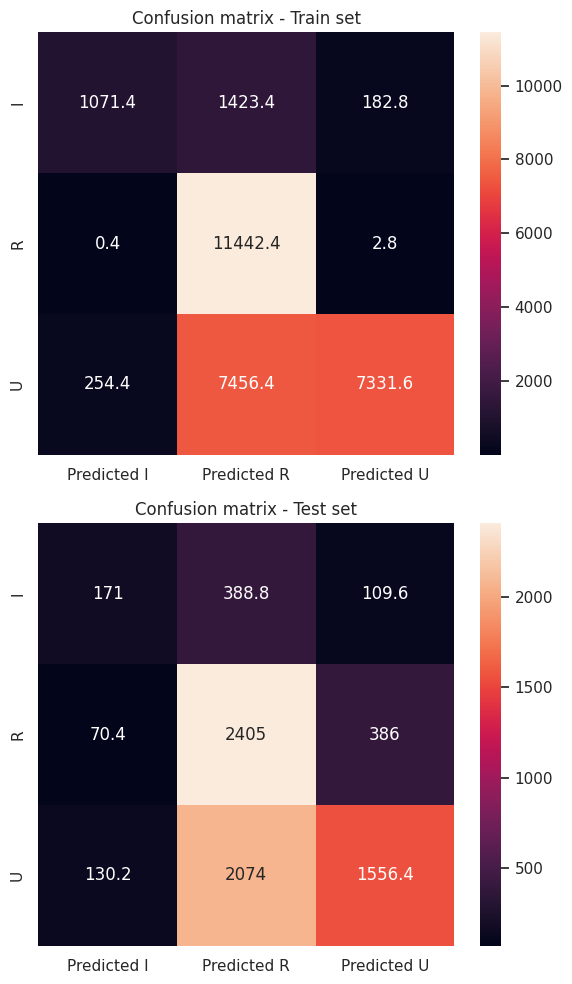

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(6, 10))

plt.subplot(2, 1, 1)
plot_confusion_matrix(mean_train_conf_matrix)
plt.title("Confusion matrix - Train set")

plt.subplot(2, 1, 2)
plot_confusion_matrix(mean_test_conf_matrix)
plt.title("Confusion matrix - Test set")

plt.subplots_adjust(hspace=-0.4)

plt.tight_layout()
plt.show()

Grazie alla matrice di confusione e all'uso dell'heatmap è possibile osservare sia i conteggi delle varie previsioni per ciascuna classe, sia le gradazioni di colori ad esse associate: colori scuri indicano minor numero di previsioni, colori chiari maggior numero. Si osserva ad esempio per la classe R, classe più rilevante, un conteggio medio di previsioni corrette pari a 2405 (colore più chiaro della legenda sulla destra) mentre 70.4 e 386 volte in media la classe R viene scambiata rispettivamente con la classe I e la classe U.